# 뇌 MRI 종양 분할 (LGG) — 팀 통합본

Kaggle LGG Segmentation (TCIA / TCGA-LGG) · 환자 110명 · 슬라이스 3,929장

## 팀원 기여

| 영역 | 담당 | 내용 |
|---|---|---|
| **실험 설계** | 윤동길 | 5-Fold 환자 단위 교차검증, 파일럿 하이퍼파라미터 탐색, 128px 입력, 전이학습 참고 실험 |
| **검증 프레임** | 본인 | 기관 × 종양비율 층화, 데이터 누수 실증, 3층 지표 체계, 실패 유형 분석, 개선 대책 사전 기각 |
| **심화 분석** | 배지수 | 환자 3D Dice, TP·FP·FN·TN 픽셀 분석, 종양 크기 구간별 성능 |

각 셀 상단에 `# [담당자]` 주석으로 기여를 표시했다.

## 설정 요약

| 항목 | 값 | 근거 |
|---|---|---|
| 입력 크기 | 128 × 128 | 소실 검증 통과 (2절) |
| MIN_PX | 5 | 면적 비율 환산 (256px 기준 20 → 128px 기준 5) |
| 분할 | 환자 단위 + 기관 × 종양비율 층화 | 슬라이스 분할 시 100% 누수 (3절) |
| 교차검증 | 5-Fold, train 74 / val 14 / test 22명 | 폴드당 학습 데이터 확보 |
| 정식화 | 1채널 sigmoid | 이진 분할 표준 |
| 모델 | M0 규칙기반 / U-Net 베이스라인 | 한 번에 하나씩 변경 |

## 임상 전제

의사가 환자 1명의 MRI를 판독하는 상황. 지표 극대화가 아니라 **놓친 종양을 줄이는 것**이 목적이다.

---
# 실행 안내

**위에서 아래로 순서대로 실행하면 된다.** 아래 사전 점검 셀을 먼저 돌려 환경을 확인할 것.

| 단계 | 소요 시간 |
|---|---|
| 0~6절 (정의) | 약 2분 |
| 7절 파일럿 탐색 | 약 5분 |
| 8절 M0 | 약 2분 |
| 9-1절 M1 5-Fold | 약 15분 |
| 9-2절 M2 5-Fold | 약 15분 |
| 10~15절 (분석) | 약 3분 |
| **합계** | **약 40분** (GPU 기준) |

## 필요한 것

- `kaggle_3m` 폴더가 이 노트북 아래 어딘가에 있을 것 (하위 폴더 포함 자동 탐색)
- 라이브러리: `torch`, `numpy`, `pandas`, `opencv-python`, `matplotlib`, `seaborn`, `scikit-learn`, `tqdm`
- GPU 권장 (CPU 로도 동작하나 매우 느림)

## 건너뛰면 안 되는 셀

- **7절 파일럿** — `BEST_LR`, `BEST_LOSS` 를 정한다. 건너뛰면 9절에서 `NameError`
- **8절 M0** — `M0_RESULT` 를 만든다. 10절 비교표에서 사용
- **9-1, 9-2절** — 둘 다 돌려야 12절 가설검정(M1 vs M2)이 동작한다


In [1]:
# [본인] 사전 점검 — 실행 전에 이 셀부터 돌릴 것
import sys, os, importlib
from glob import glob

print("=== 1. 라이브러리 ===")
need = {"torch":"torch", "numpy":"numpy", "pandas":"pandas", "cv2":"opencv-python",
        "matplotlib":"matplotlib", "seaborn":"seaborn", "sklearn":"scikit-learn", "tqdm":"tqdm"}
missing = []
for mod, pkg in need.items():
    try:
        m = importlib.import_module(mod)
        print(f"  {mod:12s} {getattr(m, '__version__', '?')}")
    except ImportError:
        missing.append(pkg); print(f"  {mod:12s} 없음")
if missing:
    print(f"\n  설치 필요:  pip install {' '.join(missing)}")

print("\n=== 2. 데이터 ===")
cands = sorted(glob("**/kaggle_3m", recursive=True))
if not cands:
    print(f"  kaggle_3m 폴더를 찾지 못했습니다")
    print(f"  현재 작업 디렉토리: {os.getcwd()}")
    print(f"  -> 데이터 압축을 이 폴더 아래에 풀어주세요")
else:
    root = cands[0]
    n_pat = len(glob(os.path.join(root, "TCGA_*")))
    n_tif = len(glob(os.path.join(root, "*", "*.tif")))
    print(f"  경로     {root}")
    print(f"  환자     {n_pat}명   (기대 110)")
    print(f"  tif 파일 {n_tif}개  (기대 7858)")
    if len(cands) > 1:
        print(f"  [주의] kaggle_3m 폴더가 {len(cands)}개 — 중복 압축 해제")

print("\n=== 3. GPU ===")
try:
    import torch
    if torch.cuda.is_available():
        print(f"  {torch.cuda.get_device_name(0)}  "
              f"{torch.cuda.get_device_properties(0).total_memory/1024**3:.1f}GB")
    else:
        print("  GPU 없음 — CPU 로 실행됩니다 (매우 느림)")
except ImportError:
    print("  torch 미설치")

print("\n=== 4. 디스크 ===")
import shutil
free = shutil.disk_usage(".").free / 1024**3
print(f"  여유 공간 {free:.1f}GB  (체크포인트 10개 약 350MB 필요)")

ok = (not missing) and cands
print("\n" + ("사전 점검 통과 — 0절부터 순서대로 실행하세요"
              if ok else "위 문제를 해결한 뒤 다시 실행하세요"))


=== 1. 라이브러리 ===
  torch        2.11.0+cu128
  numpy        1.26.4
  pandas       2.3.3
  cv2          4.11.0
  matplotlib   3.10.9
  seaborn      0.13.2
  sklearn      1.7.2
  tqdm         4.70.0

=== 2. 데이터 ===
  경로     archive\kaggle_3m
  환자     110명   (기대 110)
  tif 파일 7858개  (기대 7858)

=== 3. GPU ===
  NVIDIA GeForce RTX 5060 Laptop GPU  8.0GB

=== 4. 디스크 ===
  여유 공간 719.4GB  (체크포인트 10개 약 350MB 필요)

사전 점검 통과 — 0절부터 순서대로 실행하세요


---
# 0. 준비

`# [본인]` 환경 설정과 재현성 고정. 2~5번 노트북 공통 구조에 GPU 정보 출력을 추가했다.

In [2]:
# [본인] 라이브러리 · 시드 · device
import os, time, json, platform, gc
from glob import glob

import numpy as np
import pandas as pd
import cv2
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm.auto import tqdm

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

# [본인] 이진 분류 지표 — 4번 노트북(흉부 X-ray)과 동일한 import
#        accuracy_score 는 의도적으로 제외 (5절에서 근거 제시)
from sklearn.metrics import (recall_score, precision_score, f1_score,
                             roc_auc_score, average_precision_score,
                             confusion_matrix)

# 한글 폰트 — OS 자동 선택 (없으면 경고만 뜨고 진행)
import matplotlib.font_manager as fm
_have = {f.name for f in fm.fontManager.ttflist}
for _f in ["Malgun Gothic", "AppleGothic", "NanumGothic",
           "Noto Sans CJK KR", "Noto Sans KR"]:
    if _f in _have:
        plt.rcParams["font.family"] = _f
        break
else:
    print("[주의] 한글 폰트를 찾지 못했습니다. 그래프 한글이 깨질 수 있습니다.")
plt.rcParams["axes.unicode_minus"] = False

SEED = 42
torch.manual_seed(SEED); np.random.seed(SEED)

if torch.cuda.is_available():
    device = torch.device("cuda")
elif hasattr(torch.backends, "mps") and torch.backends.mps.is_available():
    device = torch.device("mps")
else:
    device = torch.device("cpu")

print("torch :", torch.__version__)
print("device:", device)
if device.type == "cuda":
    print("GPU   :", torch.cuda.get_device_name(0))
    print("VRAM  :", round(torch.cuda.get_device_properties(0).total_memory/1024**3, 1), "GB")
else:
    print("[경고] GPU 미사용 — 학습이 매우 느립니다")
# AMP API — torch 2.4 이전은 torch.cuda.amp 사용
_NEW_AMP = hasattr(torch, "amp") and hasattr(torch.amp, "GradScaler")
def make_scaler(enabled):
    if _NEW_AMP:
        try: return torch.amp.GradScaler("cuda", enabled=enabled)
        except TypeError: pass
    return torch.cuda.amp.GradScaler(enabled=enabled)

def autocast_ctx(enabled):
    if _NEW_AMP:
        try: return torch.amp.autocast("cuda", enabled=enabled)
        except TypeError: pass
    return torch.cuda.amp.autocast(enabled=enabled)

print("np =", np.__name__, "/ pd =", pd.__name__)
print("AMP API :", "torch.amp" if _NEW_AMP else "torch.cuda.amp")

torch : 2.11.0+cu128
device: cuda
GPU   : NVIDIA GeForce RTX 5060 Laptop GPU
VRAM  : 8.0 GB
np = numpy / pd = pandas
AMP API : torch.amp


## 0-1. 하이퍼파라미터

`# [윤동길]` 128px 입력과 5-Fold. `# [본인]` MIN_PX 환산과 재샘플링 비율.

In [3]:
# [윤동길] 입력 크기와 폴드 수
IMAGE_SIZE  = 128     # 2절 소실 검증 통과. 256 대비 학습 시간 약 1/4
K_FOLDS     = 5       # 폴드당 train 74 / val 14 / test 22명 확보

# [본인] 판정 기준과 재샘플링
MIN_PX      = 5       # 256px 기준 20 을 면적비 1/4 로 환산 (2절에서 검증)
NEG_RATIO   = 1.0     # 종양 1장당 빈 슬라이스 1장 (에폭마다 재샘플링)

# 공통
BASE        = 32
BATCH_SIZE  = 16
EPOCHS      = 30
LR          = 1e-3    # 1절 파일럿 탐색으로 재확인
USE_AMP     = (device.type == "cuda")
PIN_MEMORY  = (device.type == "cuda")
NUM_WORKERS = 0       # 윈도우 주피터는 0이 안전

print(f"IMAGE_SIZE={IMAGE_SIZE}  MIN_PX={MIN_PX}  K_FOLDS={K_FOLDS}")
print(f"BASE={BASE}  BATCH={BATCH_SIZE}  EPOCHS={EPOCHS}  NEG_RATIO={NEG_RATIO}  AMP={USE_AMP}")

IMAGE_SIZE=128  MIN_PX=5  K_FOLDS=5
BASE=32  BATCH=16  EPOCHS=30  NEG_RATIO=1.0  AMP=True


In [4]:
# [본인] 실행 환경 기록 — 보고서 재현성 항목
import sklearn, matplotlib
ENV = {
    "OS": f"{platform.system()} {platform.release()}",
    "Python": platform.python_version(),
    "torch": torch.__version__, "CUDA": torch.version.cuda,
    "GPU": torch.cuda.get_device_name(0) if torch.cuda.is_available() else "없음",
    "numpy": np.__version__, "pandas": pd.__version__,
    "opencv": cv2.__version__, "sklearn": sklearn.__version__,
    "matplotlib": matplotlib.__version__, "SEED": SEED,
}
for k, v in ENV.items():
    print(f"  {k:11s}: {v}")
with open("env.json", "w", encoding="utf-8") as f:
    json.dump(ENV, f, ensure_ascii=False, indent=2)

  OS         : Windows 10
  Python     : 3.10.11
  torch      : 2.11.0+cu128
  CUDA       : 12.8
  GPU        : NVIDIA GeForce RTX 5060 Laptop GPU
  numpy      : 1.26.4
  pandas     : 2.3.3
  opencv     : 4.11.0
  sklearn    : 1.7.2
  matplotlib : 3.10.9
  SEED       : 42


---
# 1. 데이터 인덱싱과 탐색

`# [본인]` 파일 목록을 표로 만들고 무결성을 검증한다.
`glob` 으로 **마스크를 먼저** 잡고 `_mask` 를 떼어 원본 경로를 만든다 — 원본을 먼저 잡으면
`*.tif` 패턴에 마스크까지 걸린다.

In [5]:
# [본인] 경로 탐색 + 무결성 검증
EXPECT_PATIENTS, EXPECT_IMAGES, EXPECT_MASKS = 110, 3929, 3929

cands = sorted(glob("**/kaggle_3m", recursive=True))
if not cands:
    raise FileNotFoundError(f"kaggle_3m 폴더를 못 찾았습니다.\n작업 디렉토리: {os.getcwd()}")
if len(cands) > 1:
    print(f"[주의] kaggle_3m 폴더가 {len(cands)}개 — 중복 압축 해제")
ROOT = cands[0]
print("ROOT =", ROOT)

n_patients = len(glob(os.path.join(ROOT, "TCGA_*")))
all_tif    = glob(os.path.join(ROOT, "*", "*.tif"))
n_masks    = len([p for p in all_tif if p.endswith("_mask.tif")])
n_images   = len(all_tif) - n_masks
print(f"환자 {n_patients} / 원본 {n_images} / 마스크 {n_masks}")

problems = []
if n_patients != EXPECT_PATIENTS: problems.append(f"환자 {n_patients} (기대 {EXPECT_PATIENTS})")
if n_images   != EXPECT_IMAGES:   problems.append(f"원본 {n_images} (기대 {EXPECT_IMAGES})")
if n_masks    != EXPECT_MASKS:    problems.append(f"마스크 {n_masks} (기대 {EXPECT_MASKS})")
if problems:
    raise ValueError("무결성 검증 실패:\n  - " + "\n  - ".join(problems))
print("[검증 통과]\n")

records = []
for mask_path in glob(os.path.join(ROOT, "*", "*_mask.tif")):
    img_path = mask_path.replace("_mask.tif", ".tif")
    patient  = os.path.basename(os.path.dirname(mask_path))
    slice_no = int(os.path.basename(img_path).split("_")[-1].replace(".tif", ""))
    records.append({"patient": patient, "slice": slice_no,
                    "image": img_path, "mask": mask_path})

df = pd.DataFrame(records).sort_values(["patient", "slice"]).reset_index(drop=True)
df["inst"] = df["patient"].str.split("_").str[1]      # [본인] 기관 코드 복원
print(f"슬라이스 {len(df)} / 환자 {df['patient'].nunique()} / 기관 {df['inst'].nunique()}")

ROOT = archive\kaggle_3m
환자 110 / 원본 3929 / 마스크 3929
[검증 통과]

슬라이스 3929 / 환자 110 / 기관 5


## 1-1. 클래스 불균형 — 두 층위가 곱해진다

`# [본인]` 슬라이스 단위와 픽셀 단위 불균형을 따로 본다.
4번 노트북(흉부 X-ray)은 불균형이 약 1:3이었으나 본 과제는 1:99다.

In [6]:
# [본인] 종양 유무와 픽셀 수
def tumor_stats(mask_path):
    m = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)
    return pd.Series({"tumor": int(m.max() > 0), "tumor_px": int((m > 0).sum())})

stats = df["mask"].apply(tumor_stats)
df["tumor"]    = stats["tumor"]
df["tumor_px"] = stats["tumor_px"]

print("[슬라이스 단위]")
print(df["tumor"].value_counts(normalize=True).round(3).to_string())
print()
print("[픽셀 단위]  (원본 256x256 기준)")
print(f"  전체 픽셀 중 종양: {df['tumor_px'].sum() / (len(df)*256*256) * 100:.3f} %")
print()
print("[종양 슬라이스의 종양 비중(%)]")
print((df.loc[df.tumor == 1, "tumor_px"] / (256*256) * 100).describe().round(2).to_string())

[슬라이스 단위]
tumor
0    0.651
1    0.349

[픽셀 단위]  (원본 256x256 기준)
  전체 픽셀 중 종양: 1.030 %

[종양 슬라이스의 종양 비중(%)]
count    1373.00
mean        2.95
std         2.33
min         0.01
25%         1.12
50%         2.33
75%         4.22
max        12.10


In [7]:
# [본인] 파일 수준 중복 — 빈 마스크는 내용이 전부 동일하다
n_empty, n_pos = int((df.tumor == 0).sum()), int((df.tumor == 1).sum())
print(f"tif 파일 총          {len(df)*2:,}개")
print(f"내용이 다른 파일      {len(df) + n_pos + 1:,}개")
print(f"  원본 이미지        {len(df):,}개 (전부 고유)")
print(f"  종양 마스크        {n_pos:,}개 (전부 고유)")
print(f"  빈 마스크          {n_empty:,}개 (전부 동일, 256x256 전부 0)")
print(f"\n-> 빈 마스크 비율 {n_empty/len(df):.1%} 가 곧 클래스 불균형이다")

tif 파일 총          7,858개
내용이 다른 파일      5,303개
  원본 이미지        3,929개 (전부 고유)
  종양 마스크        1,373개 (전부 고유)
  빈 마스크          2,556개 (전부 동일, 256x256 전부 0)

-> 빈 마스크 비율 65.1% 가 곧 클래스 불균형이다


## 1-2. 촬영 기관 — 제공되지 않은 정보를 복원

`# [본인]` 환자 식별자 `TCGA_<기관>_<번호>_<날짜>` 의 두 번째 필드가 기관 코드다.
데이터셋에 동봉된 `data.csv` 에는 이 정보가 없다.

In [8]:
# [본인] 기관별 분포와 FLAIR 밝기
g = df.groupby("inst").agg(환자수=("patient", "nunique"),
                           슬라이스=("patient", "size"),
                           종양비율=("tumor", "mean")).sort_values("환자수", ascending=False)

rows = []
for inst, sub in df.groupby("inst"):
    vals = []
    for p in sub.groupby("patient").head(3)["image"]:
        f = cv2.imread(p, cv2.IMREAD_UNCHANGED)[:, :, ::-1][:, :, 1] / 255.0
        brain = f > 0.05
        if brain.sum() > 0: vals.append(f[brain].mean())
    rows.append({"inst": inst, "FLAIR평균밝기": np.mean(vals)})

print(g.join(pd.DataFrame(rows).set_index("inst")).round(4).to_string())
print()
print("환자당 슬라이스 수")
print(df.groupby(["inst","patient"]).size().groupby(level=0).mean().round(1).to_string())

      환자수  슬라이스    종양비율  FLAIR평균밝기
inst                              
DU     45  1878  0.3323     0.1905
HT     34  1029  0.3926     0.2363
CS     16   358  0.3380     0.2445
FG     14   640  0.3406     0.2396
EZ      1    24  0.2500     0.2506

환자당 슬라이스 수
inst
CS    22.4
DU    41.7
EZ    24.0
FG    45.7
HT    30.3


기관마다 FLAIR 밝기가 최대 28% 차이난다. 스캐너와 프로토콜이 다르기 때문이며,
**이 정보를 3절 분할의 층화 기준으로 사용한다.**

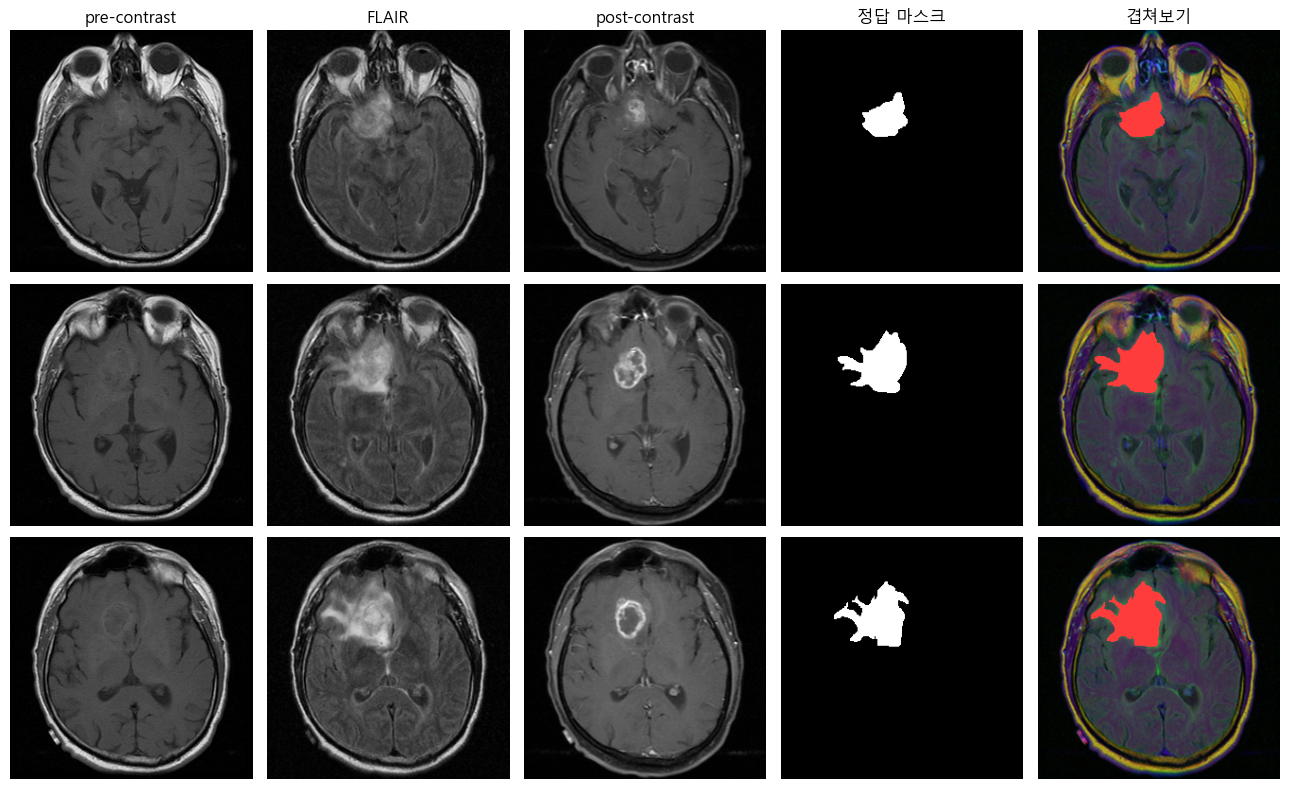

In [9]:
# [본인] 눈으로 확인 — 3채널은 RGB가 아니라 서로 다른 촬영 기법
idx = df.index[df.tumor == 1][:3]
plt.figure(figsize=(13, 8))
for r, i in enumerate(idx):
    img = cv2.imread(df.loc[i, "image"], cv2.IMREAD_UNCHANGED)[:, :, ::-1]
    msk = (cv2.imread(df.loc[i, "mask"], 0) > 127).astype(np.uint8)
    ov = img.copy(); ov[msk > 0] = [255, 60, 60]
    for j, (arr, t) in enumerate([(img[:,:,0], "pre-contrast"), (img[:,:,1], "FLAIR"),
                                  (img[:,:,2], "post-contrast"), (msk, "정답 마스크"),
                                  (ov, "겹쳐보기")]):
        plt.subplot(3, 5, r*5 + j + 1)
        plt.imshow(arr, cmap="gray" if arr.ndim == 2 else None); plt.axis("off")
        if r == 0: plt.title(t)
plt.tight_layout(); plt.show()

---
# 2. 입력 크기 결정 — 128px 소실 검증

`# [본인]` 최소 종양이 7픽셀이므로 128 축소 시 정보 손실이 우려되었다.
`# [윤동길]` 128px 로 학습 시간을 1/4 로 줄일 수 있다.

**학습 전에 검증한다.** 마스크를 nearest 보간으로 축소했을 때 종양이 실제로 소실되는지 확인한다.

In [10]:
# [본인] 128 축소 시 종양 소실 검증 (학습 불필요)
pos = df[df.tumor == 1]
rows = []
for _, r in tqdm(pos.iterrows(), total=len(pos), desc="소실 검증"):
    mk = (cv2.imread(r["mask"], cv2.IMREAD_GRAYSCALE) > 127).astype(np.uint8)
    small = cv2.resize(mk, (128, 128), interpolation=cv2.INTER_NEAREST)
    rows.append({"orig": int(mk.sum()), "small": int(small.sum())})

sz = pd.DataFrame(rows)
sz["ratio"] = sz["small"] / sz["orig"].clip(lower=1)

print(f"\n종양 슬라이스 {len(sz)}장\n")
print(f"완전 소실 (0px)     {(sz['small']==0).sum():4d}장  ({(sz['small']==0).mean()*100:5.2f}%)")
print(f"축소 후 5px 미만    {(sz['small']<5).sum():4d}장  ({(sz['small']<5).mean()*100:5.2f}%)")
print(f"축소 후 10px 미만   {(sz['small']<10).sum():4d}장  ({(sz['small']<10).mean()*100:5.2f}%)")
print(f"축소 후 20px 미만   {(sz['small']<20).sum():4d}장  ({(sz['small']<20).mean()*100:5.2f}%)")
print()
print(f"평균 면적 축소율     {sz['ratio'].mean():.4f}   (이론값 0.25)")
print(f"원본 최소 종양       {sz['orig'].min()}px -> 축소 후 {sz.loc[sz['orig'].idxmin(),'small']}px")
print()
print("MIN_PX 환산 검증")
print(f"  256px 원본, MIN_PX=20 탈락:  {(sz['orig']<20).sum()}장 ({(sz['orig']<20).mean()*100:.2f}%)")
print(f"  128px 축소, MIN_PX=5  탈락:  {(sz['small']<5).sum()}장 ({(sz['small']<5).mean()*100:.2f}%)")

소실 검증:   0%|          | 0/1373 [00:00<?, ?it/s]


종양 슬라이스 1373장

완전 소실 (0px)        0장  ( 0.00%)
축소 후 5px 미만       2장  ( 0.15%)
축소 후 10px 미만      6장  ( 0.44%)
축소 후 20px 미만     21장  ( 1.53%)

평균 면적 축소율     0.2503   (이론값 0.25)
원본 최소 종양       7px -> 축소 후 3px

MIN_PX 환산 검증
  256px 원본, MIN_PX=20 탈락:  2장 (0.15%)
  128px 축소, MIN_PX=5  탈락:  2장 (0.15%)


### 검증 결과 해석

**완전 소실 0장.** nearest 보간은 최근접 픽셀을 그대로 취하므로 소수 픽셀 종양도 보존된다.
최소 종양 7픽셀은 3픽셀로 남았다(이론상 1.75px).

**평균 축소율 0.2503** 으로 이론값(0.25)과 일치한다 — 작은 종양만 유독 손해 보는 편향이 없다.

**MIN_PX 환산도 검증되었다.** 256px 기준 20px 미만 탈락률과 128px 기준 5px 미만 탈락률이
0.15%로 동일하다. 따라서 `MIN_PX=5` 가 공정한 환산이다.

> 입력 크기 128px 채택. 정보 손실 우려는 실측으로 기각되었다.

---
# 3. 데이터 분할

`# [본인]` 환자 단위 + 기관 × 종양비율 층화.
`# [윤동길]` 5-Fold 교차검증 구조.

**이 절이 프로젝트에서 가장 중요하다.** 여기서 실수하면 이후 모든 결과가 무의미해진다.

## 3-1. 슬라이스 단위 분할의 위험 실증

`# [본인]` 4번 노트북(흉부 X-ray)의 `torch.randperm` 방식을 그대로 적용하면 어떻게 되는지 확인한다.
X-ray는 영상 한 장이 환자 한 명이므로 그 방식이 타당했으나, MRI는 환자당 평균 35.7장이다.

In [11]:
# [본인] 잘못된 방식 재현 — 실제 학습에는 사용하지 않는다
g_t = torch.Generator().manual_seed(SEED)
perm = torch.randperm(len(df), generator=g_t).tolist()
n_te = int(len(df) * 0.15)
bad_te, bad_tr = df.iloc[perm[:n_te]], df.iloc[perm[n_te:]]
overlap = set(bad_tr["patient"]) & set(bad_te["patient"])

print("[슬라이스 단위로 나눴을 때]")
print(f"  test 슬라이스 {len(bad_te)}장 / 환자 {bad_te['patient'].nunique()}명")
print(f"  그중 train 에도 존재하는 환자: {len(overlap)}명")
print(f"  -> test 환자의 {len(overlap)/bad_te['patient'].nunique()*100:.0f}% 가 train 에도 존재")
print()
print(f"  환자당 평균 슬라이스: {df.groupby('patient').size().mean():.1f}장")
print("  15%를 무작위로 떼면 모든 환자가 양쪽에 걸린다")

[슬라이스 단위로 나눴을 때]
  test 슬라이스 589장 / 환자 109명
  그중 train 에도 존재하는 환자: 109명
  -> test 환자의 100% 가 train 에도 존재

  환자당 평균 슬라이스: 35.7장
  15%를 무작위로 떼면 모든 환자가 양쪽에 걸린다


## 3-2. 5-Fold 환자 단위 층화 분할

`# [윤동길]` KFold 구조.
`# [본인]` 층화 기준 = 기관 × 종양비율 2분위.

층화가 없으면 특정 기관이 한 폴드에 몰릴 수 있다. 층마다 따로 배분하여 이를 막는다.

**층화 기준을 2개로 제한한 이유** — 환자 110명을 기관 5 × 종양비율 2 = 최대 10층으로 나누면
층당 약 11명이다. 여기에 종양 크기를 추가하면 20층·층당 5.5명이 되어 폴드 배정이 불가능해진다.

In [12]:
# [윤동길] 5-Fold 구조  +  [본인] 기관 x 종양비율 층화
def group_kfold_split(df, n_splits=K_FOLDS, seed=SEED):
    rng = np.random.default_rng(seed)
    pdf = df.drop_duplicates("patient")[["patient", "inst"]].copy()
    pdf["ratio"]  = pdf["patient"].map(df.groupby("patient")["tumor"].mean())
    pdf["bin"]    = pd.qcut(pdf["ratio"], q=2, labels=False, duplicates="drop")
    pdf["strata"] = pdf["inst"] + "_" + pdf["bin"].astype(str)

    fold_of = {}
    for st, sub in pdf.groupby("strata"):
        ids = sub["patient"].to_numpy(); rng.shuffle(ids)
        for i, p in enumerate(ids):
            fold_of[p] = i % n_splits      # 층마다 0,1,2,3,4 돌아가며 배정
    return df["patient"].map(fold_of)

df["fold"] = group_kfold_split(df)

print(df.groupby("fold").agg(환자=("patient","nunique"),
                             슬라이스=("patient","size"),
                             종양비율=("tumor","mean")).round(3).to_string())
print()
print("기관 x fold (환자 수)")
print(pd.crosstab(df.drop_duplicates("patient")["inst"],
                  df.drop_duplicates("patient")["fold"]).to_string())
print()
chk = df.groupby("patient")["fold"].nunique()
print(f"두 폴드에 걸친 환자: {(chk > 1).sum()}명 (0이어야 정상)")
assert (chk > 1).sum() == 0, "폴드 배정 오류"

      환자  슬라이스   종양비율
fold                 
0     27  1073  0.329
1     26   995  0.354
2     21   668  0.365
3     18   615  0.351
4     18   578  0.360

기관 x fold (환자 수)
fold   0   1  2  3  4
inst                 
CS     4   4  4  2  2
DU    10  10  9  8  8
EZ     1   0  0  0  0
FG     4   4  2  2  2
HT     8   8  6  6  6

두 폴드에 걸친 환자: 0명 (0이어야 정상)


## 3-3. 폴드 내 train / val 분리

`# [윤동길]` test 는 폴드 하나, 나머지 4폴드를 train+val 로 쓰고 그 안에서 val 을 15% 떼어낸다.

> **주의** — test 와 val 에 각각 폴드 하나씩을 배정하면
> 5-Fold 에서 train 이 3폴드(66명)로 줄고, 3-Fold 에서는 1폴드(약 36명)만 남는다.
> 반드시 **train+val 묶음에서 val 을 분리**해야 한다.

In [13]:
# [윤동길] 폴드별 train/val/test 구성 확인
from sklearn.model_selection import train_test_split

print(f"{'fold':>4} {'train':>7} {'val':>5} {'test':>5}   (환자 수)")
print("-" * 34)
for f in range(K_FOLDS):
    test_p = df.loc[df.fold == f, "patient"].unique()
    rest_p = df.loc[df.fold != f, "patient"].unique()
    tr_p, va_p = train_test_split(rest_p, test_size=0.15, random_state=SEED)
    print(f"{f:>4} {len(tr_p):>7} {len(va_p):>5} {len(test_p):>5}")

fold   train   val  test   (환자 수)
----------------------------------
   0      70    13    27
   1      71    13    26
   2      75    14    21
   3      78    14    18
   4      78    14    18


---
# 4. 데이터 적재와 Dataset

`# [본인]` 5번 노트북의 `build_dataset` 구조. 128px 로 리사이즈하며 **마스크는 nearest** 를 쓴다.

In [14]:
# [본인] 128px 리사이즈 적재  (마스크는 nearest 필수)
def build_dataset(sub_df, desc, size=IMAGE_SIZE):
    imgs = np.zeros((len(sub_df), size, size, 3), dtype=np.uint8)
    msks = np.zeros((len(sub_df), size, size), dtype=np.uint8)
    for i, (_, r) in enumerate(tqdm(sub_df.iterrows(), total=len(sub_df), desc=desc, leave=False)):
        im = cv2.imread(r["image"], cv2.IMREAD_UNCHANGED)[:, :, ::-1]   # BGR -> 원래 순서
        mk = (cv2.imread(r["mask"], cv2.IMREAD_GRAYSCALE) > 127).astype(np.uint8)
        if size != 256:
            im = cv2.resize(im, (size, size), interpolation=cv2.INTER_AREA)
            mk = cv2.resize(mk, (size, size), interpolation=cv2.INTER_NEAREST)
        imgs[i], msks[i] = im, mk
    return imgs, msks


def compute_norm_stats(imgs):
    """[본인] train 에서만, float64 누적 (float32 는 반올림으로 2% 왜곡)"""
    s, ss, n = np.zeros(3), np.zeros(3), 0
    for i in range(0, len(imgs), 500):
        ch = imgs[i:i+500].astype(np.float64).reshape(-1, 3) / 255.0
        s  += ch.sum(0, dtype=np.float64)
        ss += (ch ** 2).sum(0, dtype=np.float64)
        n  += len(ch)
    mean = (s / n).astype(np.float32)
    std  = np.sqrt(ss / n - (s / n) ** 2).astype(np.float32)
    return mean, std

print("build_dataset / compute_norm_stats 정의 완료")

build_dataset / compute_norm_stats 정의 완료


## 4-1. Dataset — 빈 슬라이스 에폭별 재샘플링

`# [본인]` train 의 빈 슬라이스를 다 넣으면 학습이 희석되고, 다 빼면 오탐이 폭발한다.
**매 에폭 다르게 뽑아 섞으므로** 데이터를 버리는 것이 아니라 한 에폭 안의 비율만 조절한다.

증강은 `torchvision.transforms` 를 쓸 수 없다 — 이미지만 뒤집고 마스크는 그대로 두어
정답이 어긋나기 때문이다. numpy 로 직접 구현하여 **이미지와 마스크에 동일한 기하 변환**을 적용한다.

In [15]:
# [본인] SegDataset — 재샘플링 + 이미지·마스크 동시 증강
class SegDataset(Dataset):
    def __init__(self, imgs, msks, sub_df, mean, std,
                 neg_ratio=None, augment=False, seed=SEED):
        self.imgs, self.msks, self.sub = imgs, msks, sub_df
        self.mean, self.std = mean, std
        self.neg_ratio, self.augment = neg_ratio, augment
        self.pos_idx = np.where(sub_df["tumor"].values == 1)[0]
        self.neg_idx = np.where(sub_df["tumor"].values == 0)[0]
        self.rng = np.random.default_rng(seed)
        self.resample_epoch()

    def resample_epoch(self):
        if self.neg_ratio is None:                 # val / test 는 전체 사용
            self.rows = np.arange(len(self.sub)); return
        k = min(int(len(self.pos_idx) * self.neg_ratio), len(self.neg_idx))
        pick = self.rng.choice(self.neg_idx, size=k, replace=False)
        self.rows = np.concatenate([self.pos_idx, pick])

    def __len__(self):
        return len(self.rows)

    def __getitem__(self, i):
        j = self.rows[i]
        img = self.imgs[j].astype(np.float32) / 255.0
        msk = self.msks[j].astype(np.float32)

        if self.augment:                            # 기하 변환: 이미지 + 마스크
            if self.rng.random() < 0.5: img, msk = img[:, ::-1], msk[:, ::-1]
            if self.rng.random() < 0.5: img, msk = img[::-1],    msk[::-1]
            k = int(self.rng.integers(4))
            if k: img, msk = np.rot90(img, k), np.rot90(msk, k)
            img, msk = np.ascontiguousarray(img), np.ascontiguousarray(msk)

        img = np.transpose((img - self.mean) / self.std, (2, 0, 1))   # 정규화는 이미지만
        return torch.from_numpy(img).float(), torch.from_numpy(msk)[None].float()

print("SegDataset 정의 완료")

SegDataset 정의 완료


---
# 5. 모델과 손실함수

`# [본인]` 5번 노트북의 U-Net 구조를 이진 분할로 변환.

| 항목 | 5번 (30클래스) | 본 연구 (이진) |
|---|---|---|
| 출력 채널 | 30 | **1** |
| 손실 | CrossEntropyLoss | **BCEWithLogitsLoss + Dice** |
| 마스크 | int64 `(B,H,W)` | **float32 `(B,1,H,W)`** |
| 예측 | `argmax(1)` | **`sigmoid() > threshold`** |

**skip connection 이 필수인 이유** — 인코더는 128→64→32→16→8 로 해상도를 줄인다.
출력은 다시 128×128 이어야 하는데, 8×8 에서 복원하면 위치가 뭉개진다.

In [16]:
# [본인] U-Net  (5번 노트북 구조 + 2번 노트북 BatchNorm)
def conv2d_block(in_ch, out_ch, kernel_size=3, use_bn=True):
    layers = []
    for i in range(2):
        layers += [nn.Conv2d(in_ch if i == 0 else out_ch, out_ch, kernel_size,
                             padding=kernel_size // 2, bias=not use_bn)]
        if use_bn: layers += [nn.BatchNorm2d(out_ch)]
        layers += [nn.ReLU(inplace=True)]
    return nn.Sequential(*layers)


class EncoderBlock(nn.Module):
    def __init__(self, in_ch, out_ch, dropout=0.2, use_bn=True):
        super().__init__()
        self.conv = conv2d_block(in_ch, out_ch, use_bn=use_bn)
        self.pool = nn.MaxPool2d(2); self.drop = nn.Dropout(dropout)
    def forward(self, x):
        f = self.conv(x)
        return f, self.drop(self.pool(f))


class DecoderBlock(nn.Module):
    def __init__(self, in_ch, skip_ch, out_ch, dropout=0.2, use_bn=True):
        super().__init__()
        self.up   = nn.ConvTranspose2d(in_ch, out_ch, 3, stride=2, padding=1, output_padding=1)
        self.drop = nn.Dropout(dropout)
        self.conv = conv2d_block(out_ch + skip_ch, out_ch, use_bn=use_bn)
    def forward(self, x, skip):
        return self.conv(self.drop(torch.cat([self.up(x), skip], dim=1)))


class UNet(nn.Module):
    def __init__(self, base=BASE, in_ch=3, n_classes=1, use_bn=True):
        super().__init__()
        b = base
        self.enc1 = EncoderBlock(in_ch, b,   use_bn=use_bn)
        self.enc2 = EncoderBlock(b,     b*2, use_bn=use_bn)
        self.enc3 = EncoderBlock(b*2,   b*4, use_bn=use_bn)
        self.enc4 = EncoderBlock(b*4,   b*8, use_bn=use_bn)
        self.bottleneck = conv2d_block(b*8, b*16, use_bn=use_bn)
        self.dec1 = DecoderBlock(b*16, b*8, b*8, use_bn=use_bn)
        self.dec2 = DecoderBlock(b*8,  b*4, b*4, use_bn=use_bn)
        self.dec3 = DecoderBlock(b*4,  b*2, b*2, use_bn=use_bn)
        self.dec4 = DecoderBlock(b*2,  b,   b,   use_bn=use_bn)
        self.out  = nn.Conv2d(b, n_classes, 1)
        self._init_weights()

    def _init_weights(self):                        # [본인] 2번 노트북 initializer_weights
        for m in self.modules():
            if isinstance(m, (nn.Conv2d, nn.ConvTranspose2d)):
                nn.init.kaiming_normal_(m.weight, nonlinearity="relu")
                if m.bias is not None: nn.init.zeros_(m.bias)

    def forward(self, x):
        f1, p1 = self.enc1(x); f2, p2 = self.enc2(p1)
        f3, p3 = self.enc3(p2); f4, p4 = self.enc4(p3)
        c = self.bottleneck(p4)
        c = self.dec1(c, f4); c = self.dec2(c, f3)
        c = self.dec3(c, f2); c = self.dec4(c, f1)
        return self.out(c)


_m = UNet()
with torch.no_grad():
    print("출력 shape:", tuple(_m(torch.zeros(1, 3, IMAGE_SIZE, IMAGE_SIZE)).shape))
print("파라미터  :", f"{sum(p.numel() for p in _m.parameters()):,}")
del _m

출력 shape: (1, 1, 128, 128)
파라미터  : 8,633,441


## 5-1. 손실함수

`# [본인]` BCE 단독은 위험하다 — 종양이 1%뿐이라 "전부 배경"이라 답해도 손실이 낮다.
**Dice 는 배경을 세지 않으므로** 그 함정을 막는다.

**두 가지 함정**

| 함정 | 증상 | 대응 |
|---|---|---|
| 빈 마스크에서 0/0 | nan 발생 → 가중치 전체 오염 | `smooth = 1.0` |
| AMP float16 오버플로 | 픽셀 합이 한계 초과 → 손실 1.0 고정. **오류도 nan도 없음** | `logits.float()` + GradScaler |

In [17]:
# [본인] BCE + Dice
class BCEDiceLoss(nn.Module):
    def __init__(self, w_bce=0.5, smooth=1.0):
        super().__init__()
        self.bce = nn.BCEWithLogitsLoss()
        self.w, self.s = w_bce, smooth
    def forward(self, logits, target):
        logits, target = logits.float(), target.float()      # AMP 오버플로 방지
        bce = self.bce(logits, target)
        p = torch.sigmoid(logits)
        inter = (p * target).sum(dim=(1, 2, 3))
        den   = p.sum(dim=(1, 2, 3)) + target.sum(dim=(1, 2, 3))
        dice  = 1 - ((2*inter + self.s) / (den + self.s)).mean()
        return self.w * bce + (1 - self.w) * dice


class BCELoss(nn.Module):
    """[본인] BCE 단독 — 베이스라인용"""
    def __init__(self):
        super().__init__(); self.bce = nn.BCEWithLogitsLoss()
    def forward(self, logits, target):
        return self.bce(logits.float(), target.float())

print("손실함수 정의 완료")

손실함수 정의 완료


## 5-2. 평가 지표 — 3층 체계

`# [본인]` 지표마다 답하는 질문이 다르다. 하나만 보면 반드시 속는다.

| 층위 | 지표 | 답하는 질문 | 용도 |
|---|---|---|---|
| 외부 비교 | Dice | 선행 연구 대비 어디쯤인가 | 논문·공개 구현 대조 |
| 1층 | **PR-AUC** | 어느 모델이 나은가 | 모델 선택 (임계값 무관) |
| 2층 | recall / precision / 체적비 | 실제 성능은 어떤가 | 운영점 판단 |
| 3층 | 놓친 환자 / 최소 Dice / 편차 | 쓸 수 있는가 | 임상 적용 판단 |

`accuracy_score` 는 제외한다 — 6절 M0 에서 근거를 제시한다.

In [18]:
# [본인] matplotlib 버전 호환 — 3.9부터 labels -> tick_labels
import matplotlib as _mpl
_MPL_NEW = tuple(int(x) for x in _mpl.__version__.split(".")[:2]) >= (3, 9)
def boxplot_compat(ax, data, labels, **kw):
    key = "tick_labels" if _MPL_NEW else "labels"
    return ax.boxplot(data, **{key: labels}, **kw)

# [본인] 지표 — 누적 후 나누기 (슬라이스별 평균은 작은 종양을 과대 반영)
def dice_score(probs, trues, threshold=0.5, smooth=1e-6):
    p, t = probs > threshold, trues > 0.5
    return (2*(p & t).sum() + smooth) / (p.sum() + t.sum() + smooth)

def iou_score(probs, trues, threshold=0.5, smooth=1e-6):
    p, t = probs > threshold, trues > 0.5
    return ((p & t).sum() + smooth) / ((p | t).sum() + smooth)

def pixel_recall(probs, trues, threshold=0.5):
    p, t = probs > threshold, trues > 0.5
    return (p & t).sum() / max(t.sum(), 1)

def volume_ratio(probs, trues, threshold=0.5):
    """예측 체적 / 정답 체적. 1.0이 정확, 2.0이면 2배 과대평가"""
    return (probs > threshold).sum() / max((trues > 0.5).sum(), 1)


@torch.no_grad()
def evaluate_seg(model, loader):
    """[본인] 4번 노트북 evaluation() 구조 — 확률과 정답을 모아 반환"""
    model.eval()
    probs, trues = [], []
    for xb, yb in loader:
        with autocast_ctx(USE_AMP):
            logits = model(xb.to(device))
        probs.append(torch.sigmoid(logits.float()).cpu())
        trues.append(yb)
    return torch.cat(probs).numpy()[:, 0], torch.cat(trues).numpy()[:, 0]


def threshold_sweep(probs, trues, ths=np.arange(0.05, 0.96, 0.05)):
    return pd.DataFrame([{"th": round(float(t), 2),
                          "dice": float(dice_score(probs, trues, t)),
                          "recall": float(pixel_recall(probs, trues, t)),
                          "vol_ratio": float(volume_ratio(probs, trues, t))} for t in ths])

def pick_threshold(sw, tol=0.98):
    """[본인] 최고점이 아니라 고원(최고의 98% 이상) 중앙값 — val 표본이 작아 최고점은 우연일 수 있다"""
    top = sw[sw["dice"] >= sw["dice"].max() * tol]
    return float(top["th"].median())

print("지표 함수 정의 완료")

지표 함수 정의 완료


---
# 6. 학습 함수

`# [본인]` 5번 노트북 `train_unet` 구조에 세 가지를 변경했다.

1. **체크포인트 기준을 val Dice 로** — val_loss 나 픽셀 정확도로 저장하면 "전부 배경" 모델이 최고점으로 남는다
2. **train Dice 도 기록** — 과적합 격차를 보려면 loss 만으로는 부족하다
3. **AMP** — 순전파는 float16, **손실은 autocast 밖에서 float32**

In [19]:
# [본인] 학습 함수
def train_unet(criterion, tr_ds, tr_ld, va_ld, use_bn=True,
               epochs=EPOCHS, lr=LR, seed=SEED, tag="M"):
    torch.manual_seed(seed); np.random.seed(seed)
    model  = UNet(base=BASE, use_bn=use_bn).to(device)
    opt    = torch.optim.Adam(model.parameters(), lr=lr)
    sched  = torch.optim.lr_scheduler.CosineAnnealingLR(opt, T_max=epochs)   # 2번 노트북
    scaler = make_scaler(USE_AMP)

    history = {"loss": [], "train_dice": [], "val_dice": [], "sec": []}
    best, ckpt = -1.0, f"lgg_{tag}.pt"

    for ep in range(1, epochs + 1):
        tr_ds.resample_epoch()                    # 빈 슬라이스를 매 에폭 새로 뽑는다
        model.train()
        t0, run = time.time(), 0.0
        inter = psum = tsum = 0.0

        for xb, yb in tr_ld:
            xb, yb = xb.to(device), yb.to(device)
            opt.zero_grad(set_to_none=True)
            with autocast_ctx(USE_AMP):
                logits = model(xb)
            loss = criterion(logits, yb)           # 손실은 autocast 밖 (float32)
            scaler.scale(loss).backward()
            scaler.step(opt); scaler.update()
            run += loss.item() * xb.size(0)
            with torch.no_grad():
                p = (torch.sigmoid(logits.float()) > 0.5).float()
                inter += (p * yb).sum().item()
                psum  += p.sum().item(); tsum += yb.sum().item()

        sched.step()
        vp, vt  = evaluate_seg(model, va_ld)
        va_dice = float(dice_score(vp, vt, 0.5))
        for k, v in zip(["loss","train_dice","val_dice","sec"],
                        [run/len(tr_ds), 2*inter/max(psum+tsum,1), va_dice, time.time()-t0]):
            history[k].append(v)
        if va_dice > best:
            best = va_dice; torch.save(model.state_dict(), ckpt)
        if ep % 5 == 0 or ep == 1:
            print(f"  [{tag}] {ep:2d}/{epochs}  loss {history['loss'][-1]:.4f}  "
                  f"train {history['train_dice'][-1]:.4f}  val {va_dice:.4f}  "
                  f"{history['sec'][-1]:.1f}초")

    gap = history["train_dice"][-1] - history["val_dice"][-1]
    print(f"  [{tag}] 최고 val Dice {best:.4f} | 에폭 평균 {np.mean(history['sec']):.1f}초 | "
          f"과적합 격차 {gap:+.4f}")
    model.load_state_dict(torch.load(ckpt, map_location=device))
    return model, history

print("train_unet 정의 완료")

train_unet 정의 완료


---
# 7. 파일럿 하이퍼파라미터 탐색

`# [윤동길]` 본 학습 전에 폴드와 무관한 파일럿 분할로 후보를 짧게 비교한다.
**이 분할은 하이퍼파라미터 선택에만 쓰이고 최종 평가에는 사용하지 않는다.**

In [20]:
# [윤동길] 파일럿 분할로 lr x 손실 조합 비교
PILOT_EPOCHS = 5

pilot_test = df.loc[df.fold == 0, "patient"].unique()      # fold 0 은 파일럿에서 제외
rest       = df.loc[df.fold != 0, "patient"].unique()
p_tr, p_va = train_test_split(rest, test_size=0.2, random_state=SEED)

pdf_tr = df[df.patient.isin(p_tr)].reset_index(drop=True)
pdf_va = df[df.patient.isin(p_va)].reset_index(drop=True)
pi_tr, pm_tr = build_dataset(pdf_tr, "Pilot Train")
pi_va, pm_va = build_dataset(pdf_va, "Pilot Val")
p_mean, p_std = compute_norm_stats(pi_tr)

candidates = [
    {"lr": 1e-3, "loss": "BCE"},
    {"lr": 1e-4, "loss": "BCE"},
    {"lr": 1e-3, "loss": "BCE+Dice"},
]
pilot_results = []
for cand in candidates:
    crit = BCELoss() if cand["loss"] == "BCE" else BCEDiceLoss()
    ds = SegDataset(pi_tr, pm_tr, pdf_tr, p_mean, p_std, neg_ratio=NEG_RATIO, augment=True)
    ld = DataLoader(ds, batch_size=BATCH_SIZE, shuffle=True,
                    num_workers=NUM_WORKERS, pin_memory=PIN_MEMORY)
    vds = SegDataset(pi_va, pm_va, pdf_va, p_mean, p_std, neg_ratio=None, augment=False)
    vld = DataLoader(vds, batch_size=BATCH_SIZE, shuffle=False,
                     num_workers=NUM_WORKERS, pin_memory=PIN_MEMORY)

    torch.manual_seed(SEED); np.random.seed(SEED)
    m = UNet(base=BASE, use_bn=True).to(device)
    opt = torch.optim.Adam(m.parameters(), lr=cand["lr"])
    scaler = make_scaler(USE_AMP)
    best = -1.0
    for ep in range(PILOT_EPOCHS):
        ds.resample_epoch(); m.train()
        for xb, yb in ld:
            xb, yb = xb.to(device), yb.to(device)
            opt.zero_grad(set_to_none=True)
            with autocast_ctx(USE_AMP):
                logits = m(xb)
            loss = crit(logits, yb)
            scaler.scale(loss).backward(); scaler.step(opt); scaler.update()
        vp, vt = evaluate_seg(m, vld)
        best = max(best, float(dice_score(vp, vt, 0.5)))
    print(f"lr={cand['lr']:<7} loss={cand['loss']:<9} -> {PILOT_EPOCHS}에폭 최고 val Dice = {best:.4f}")
    pilot_results.append({**cand, "val_dice": best})
    del m, ds, ld, vds, vld; gc.collect()
    if device.type == "cuda": torch.cuda.empty_cache()

best_cand = max(pilot_results, key=lambda x: x["val_dice"])
BEST_LR   = best_cand["lr"]
BEST_LOSS = best_cand["loss"]
print(f"\n선택: lr={BEST_LR}, loss={BEST_LOSS} (val Dice={best_cand['val_dice']:.4f})")

del pi_tr, pm_tr, pi_va, pm_va; gc.collect()

Pilot Train:   0%|          | 0/2274 [00:00<?, ?it/s]

Pilot Val:   0%|          | 0/582 [00:00<?, ?it/s]

lr=0.001   loss=BCE       -> 5에폭 최고 val Dice = 0.6261
lr=0.0001  loss=BCE       -> 5에폭 최고 val Dice = 0.5633
lr=0.001   loss=BCE+Dice  -> 5에폭 최고 val Dice = 0.6088

선택: lr=0.001, loss=BCE (val Dice=0.6261)


0

---
# 8. M0 — 규칙 기반 베이스라인 (학습 없음)

`# [본인]` 2번 노트북에서 SimpleCNN 이전에 SimpleDNN 으로 기준점을 잡은 것과 같은 구조.
FLAIR 강도에 Otsu 임계값을 걸고 가장 큰 덩어리만 남긴다.

**이 결과가 두 가지를 증명한다.**
① 픽셀 정확도는 쓸 수 없다 ② 재현율 단독도 쓸 수 없다

In [21]:
# [본인] M0 — FLAIR + Otsu + 최대 연결성분
def otsu_predict(img_u8):
    flair = img_u8[:, :, 1]
    brain = flair > 12
    if brain.sum() < 100:
        return np.zeros_like(flair, np.uint8)
    t, _ = cv2.threshold(flair[brain], 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
    pred = ((flair > t) & brain).astype(np.uint8)
    n, lab, stats, _ = cv2.connectedComponentsWithStats(pred, 8)
    if n <= 1: return pred
    k = 1 + np.argmax(stats[1:, cv2.CC_STAT_AREA])
    return (lab == k).astype(np.uint8)


# 전체 110명(=모든 폴드)에 대해 평가 — 학습이 없으므로 분할이 필요 없다
all_sub = df.reset_index(drop=True)
all_imgs, all_msks = build_dataset(all_sub, "M0 전체")
P0 = np.stack([otsu_predict(im) for im in all_imgs]).astype(np.float32)
f0 = (P0.sum(axis=(1,2)) > MIN_PX).astype(int)
t0 = all_sub["tumor"].values

print("=== M0 규칙 기반 (Otsu, 학습 없음) ===")
print(f"픽셀 Dice        {dice_score(P0, all_msks):.4f}")
print(f"픽셀 재현율      {pixel_recall(P0, all_msks):.4f}   <- 경계 품질")
print(f"체적비           {volume_ratio(P0, all_msks):.2f}배  <- 1.0이 정확")
print(f"슬라이스 재현율   {recall_score(t0, f0, zero_division=0):.4f}   <- 놓친 종양")
print(f"슬라이스 정밀도   {precision_score(t0, f0, zero_division=0):.4f}")
print()
print("=== 무학습 하한선 ===")
print(f"전부 배경        Dice 0.0000, 픽셀 정확도 {1 - all_msks.mean():.4f}")
print(f"항상 종양 있음    슬라이스 재현율 1.0000, 정밀도 {t0.mean():.4f}")

M0_RESULT = {
    "dice": float(dice_score(P0, all_msks)),
    "pixel_recall": float(pixel_recall(P0, all_msks)),
    "vol": float(volume_ratio(P0, all_msks)),
    "slice_recall": float(recall_score(t0, f0, zero_division=0)),
    "slice_precision": float(precision_score(t0, f0, zero_division=0)),
    "bg_accuracy": float(1 - all_msks.mean()),
}
del all_imgs, all_msks, P0; gc.collect()

M0 전체:   0%|          | 0/3929 [00:00<?, ?it/s]

=== M0 규칙 기반 (Otsu, 학습 없음) ===
픽셀 Dice        0.1289
픽셀 재현율      0.4566   <- 경계 품질
체적비           6.09배  <- 1.0이 정확
슬라이스 재현율   1.0000   <- 놓친 종양
슬라이스 정밀도   0.3647

=== 무학습 하한선 ===
전부 배경        Dice 0.0000, 픽셀 정확도 0.9897
항상 종양 있음    슬라이스 재현율 1.0000, 정밀도 0.3495


46

### M0 가 증명하는 것

**① 픽셀 정확도는 쓸 수 없다.** 아무것도 예측하지 않아도 0.98 이상이 나온다.
4번(흉부 X-ray)에서 `accuracy_score` 를 쓴 것은 불균형이 1:3이라 타당했으나, 여기는 1:99다.

**② 재현율 단독도 쓸 수 없다.** M0 는 슬라이스 재현율 1.0000 을 달성했지만
체적을 3배 이상 과대예측한다. 종양 픽셀의 3분의 1만 덮으면서 면적은 3배로 그린 것이다.

> **재현율은 목표가 아니라 제약 조건이어야 한다.**

---
# 9. 5-Fold 교차검증

`# [윤동길]` 폴드 구조.
`# [본인]` 폴드마다 데이터 재구성 · 정규화 통계 재계산 · 임계값 재결정.

폴드마다 통계를 다시 계산하는 이유는, 한 번 계산해 재사용하면
그 폴드의 test 환자가 통계에 포함되어 **누수**가 되기 때문이다.

> **전역 상태 보호** — 이 함수는 지역 변수만 사용하며 전역을 덮어쓰지 않는다.

In [22]:
# [윤동길] 5-Fold 구조  +  [본인] 폴드별 통계·임계값 재계산
def run_cv(criterion_name="BCE", use_bn=True, epochs=EPOCHS, lr=None,
           n_splits=K_FOLDS, tag="CV"):
    lr = lr if lr is not None else BEST_LR
    fold_rows, all_patient_dice, all_slice_records = [], {}, []

    for f in range(n_splits):
        print(f"\n===== Fold {f+1}/{n_splits} =====")
        test_p = df.loc[df.fold == f, "patient"].unique()
        rest_p = df.loc[df.fold != f, "patient"].unique()
        tr_p, va_p = train_test_split(rest_p, test_size=0.15, random_state=SEED)
        print(f"  train {len(tr_p)}명 / val {len(va_p)}명 / test {len(test_p)}명")

        sub = {k: df[df.patient.isin(v)].reset_index(drop=True)
               for k, v in [("train", tr_p), ("val", va_p), ("test", test_p)]}
        arr = {k: build_dataset(sub[k], f"F{f} {k}") for k in sub}
        mean, std = compute_norm_stats(arr["train"][0])   # 이 폴드 train 에서만

        crit = BCELoss() if criterion_name == "BCE" else BCEDiceLoss()
        tr_ds = SegDataset(*arr["train"], sub["train"], mean, std,
                           neg_ratio=NEG_RATIO, augment=True)
        va_ds = SegDataset(*arr["val"],   sub["val"],   mean, std, neg_ratio=None)
        te_ds = SegDataset(*arr["test"],  sub["test"],  mean, std, neg_ratio=None)
        kw = dict(num_workers=NUM_WORKERS, pin_memory=PIN_MEMORY)
        tr_ld = DataLoader(tr_ds, batch_size=BATCH_SIZE, shuffle=True,  **kw)
        va_ld = DataLoader(va_ds, batch_size=BATCH_SIZE, shuffle=False, **kw)
        te_ld = DataLoader(te_ds, batch_size=BATCH_SIZE, shuffle=False, **kw)

        model, hist = train_unet(crit, tr_ds, tr_ld, va_ld, use_bn=use_bn,
                                 epochs=epochs, lr=lr, tag=f"{tag}_f{f}")

        vp, vt = evaluate_seg(model, va_ld)              # 임계값은 이 폴드 val 에서만
        t = pick_threshold(threshold_sweep(vp, vt))

        tp_, tt_ = evaluate_seg(model, te_ld)
        te_sub = sub["test"]
        has  = te_sub["tumor"].values.astype(bool)
        pf   = ((tp_ > t).sum(axis=(1,2)) > MIN_PX).astype(int)
        area = (tp_ > t).sum(axis=(1,2)) / IMAGE_SIZE**2

        # [배지수] 슬라이스별 TP/FP/FN/TN 기록
        pred_b, true_b = tp_ > t, tt_ > 0.5
        for i in range(len(te_sub)):
            tp_i = int((pred_b[i] &  true_b[i]).sum()); fp_i = int((pred_b[i] & ~true_b[i]).sum())
            fn_i = int((~pred_b[i] & true_b[i]).sum()); tn_i = int((~pred_b[i] & ~true_b[i]).sum())
            den = 2*tp_i + fp_i + fn_i
            all_slice_records.append({
                "fold": f, "patient": te_sub.loc[i, "patient"], "slice": int(te_sub.loc[i, "slice"]),
                "tp": tp_i, "fp": fp_i, "fn": fn_i, "tn": tn_i,
                "tumor_px": tp_i + fn_i, "pred_px": tp_i + fp_i,
                "dice": float(2*tp_i/den) if den else 1.0,
            })

        missed = 0
        for p, gp in te_sub.groupby("patient"):
            k = gp.index.values
            all_patient_dice[p] = float(dice_score(tp_[k], tt_[k], t))
            if (has[k] & (pf[k] == 0)).any(): missed += 1

        fold_rows.append({
            "fold": f, "th": round(t, 2), "n_test": len(test_p),
            "dice": float(dice_score(tp_, tt_, t)),
            "dice_pos": float(dice_score(tp_[has], tt_[has], t)),
            "iou": float(iou_score(tp_, tt_, t)),
            "recall": recall_score(has.astype(int), pf, zero_division=0),
            "precision": precision_score(has.astype(int), pf, zero_division=0),
            "prauc": average_precision_score(has.astype(int), area),
            "vol": float(volume_ratio(tp_, tt_, t)),
            "missed": missed,
            "gap": hist["train_dice"][-1] - hist["val_dice"][-1],
        })
        r = fold_rows[-1]
        print(f"  Fold{f}  th {r['th']:.2f}  Dice {r['dice']:.4f}  recall {r['recall']:.4f}  "
              f"PR-AUC {r['prauc']:.4f}  놓친환자 {missed}/{len(test_p)}")

        del arr, tr_ds, va_ds, te_ds, tr_ld, va_ld, te_ld, model; gc.collect()
        if device.type == "cuda": torch.cuda.empty_cache()

    return pd.DataFrame(fold_rows), all_patient_dice, pd.DataFrame(all_slice_records)

print("run_cv 정의 완료")

run_cv 정의 완료


## 9-1. M1 — BCE 단독 베이스라인 (5-Fold)

In [23]:
# [윤동길] 5-Fold 실행  ·  [본인] M1 = 5번 노트북 구조 (BCE 단독, BatchNorm 없음)
cv1, pd1, sl1 = run_cv(criterion_name="BCE", use_bn=False, tag="M1")


===== Fold 1/5 =====
  train 70명 / val 13명 / test 27명


F0 train:   0%|          | 0/2383 [00:00<?, ?it/s]

F0 val:   0%|          | 0/473 [00:00<?, ?it/s]

F0 test:   0%|          | 0/1073 [00:00<?, ?it/s]

  [M1_f0]  1/30  loss 0.0828  train 0.3664  val 0.4140  4.4초
  [M1_f0]  5/30  loss 0.0252  train 0.7048  val 0.5658  4.3초
  [M1_f0] 10/30  loss 0.0165  train 0.7982  val 0.6738  4.4초
  [M1_f0] 15/30  loss 0.0121  train 0.8534  val 0.7371  4.2초
  [M1_f0] 20/30  loss 0.0101  train 0.8769  val 0.7610  4.3초
  [M1_f0] 25/30  loss 0.0088  train 0.8892  val 0.7595  4.5초
  [M1_f0] 30/30  loss 0.0081  train 0.8971  val 0.7587  4.4초
  [M1_f0] 최고 val Dice 0.7788 | 에폭 평균 4.4초 | 과적합 격차 +0.1383
  Fold0  th 0.50  Dice 0.7754  recall 0.9150  PR-AUC 0.8743  놓친환자 15/27

===== Fold 2/5 =====
  train 71명 / val 13명 / test 26명


...

  [M1_f3]  1/30  loss 0.0577  train 0.4103  val 0.5408  5.0초
  [M1_f3]  5/30  loss 0.0263  train 0.6502  val 0.7567  4.9초
  [M1_f3] 10/30  loss 0.0156  train 0.8038  val 0.7862  5.0초
  [M1_f3] 15/30  loss 0.0124  train 0.8450  val 0.7800  5.1초
  [M1_f3] 20/30  loss 0.0097  train 0.8747  val 0.8550  5.1초
  [M1_f3] 25/30  loss 0.0088  train 0.8852  val 0.8726  5.1초
  [M1_f3] 30/30  loss 0.0085  train 0.8884  val 0.8704  5.1초
  [M1_f3] 최고 val Dice 0.8726 | 에폭 평균 5.1초 | 과적합 격차 +0.0180
  Fold3  th 0.47  Dice 0.6224  recall 0.8657  PR-AUC 0.7520  놓친환자 9/18

===== Fold 5/5 =====
  train 78명 / val 14명 / test 18명


F4 train:   0%|          | 0/2826 [00:00<?, ?it/s]

F4 val:   0%|          | 0/525 [00:00<?, ?it/s]

F4 test:   0%|          | 0/578 [00:00<?, ?it/s]

  [M1_f4]  1/30  loss 0.0563  train 0.3481  val 0.4457  5.1초
  [M1_f4]  5/30  loss 0.0257  train 0.6592  val 0.7146  4.9초
  [M1_f4] 10/30  loss 0.0165  train 0.7886  val 0.7836  5.0초
  [M1_f4] 15/30  loss 0.0113  train 0.8554  val 0.8203  5.0초
  [M1_f4] 20/30  loss 0.0096  train 0.8763  val 0.8069  5.1초
  [M1_f4] 25/30  loss 0.0088  train 0.8857  val 0.8159  5.1초
  [M1_f4] 30/30  loss 0.0083  train 0.8906  val 0.8208  5.1초
  [M1_f4] 최고 val Dice 0.8314 | 에폭 평균 5.0초 | 과적합 격차 +0.0698
  Fold4  th 0.47  Dice 0.8233  recall 0.9183  PR-AUC 0.9359  놓친환자 10/18


## 9-2. M2 — BatchNorm + BCE·Dice (5-Fold)

In [24]:
# [본인] M2 = M1 + BatchNorm(2번 노트북) + Dice 항
cv2_, pd2, sl2 = run_cv(criterion_name="BCE+Dice", use_bn=True, tag="M2")


===== Fold 1/5 =====
  train 70명 / val 13명 / test 27명


F0 train:   0%|          | 0/2383 [00:00<?, ?it/s]

F0 val:   0%|          | 0/473 [00:00<?, ?it/s]

F0 test:   0%|          | 0/1073 [00:00<?, ?it/s]

  [M2_f0]  1/30  loss 0.5099  train 0.4680  val 0.5178  4.6초
  [M2_f0]  5/30  loss 0.3426  train 0.7250  val 0.5705  4.6초
  [M2_f0] 10/30  loss 0.1693  train 0.6923  val 0.6145  4.8초
  [M2_f0] 15/30  loss 0.1512  train 0.7372  val 0.5553  4.6초
  [M2_f0] 20/30  loss 0.1400  train 0.7618  val 0.6374  4.7초
  [M2_f0] 25/30  loss 0.1245  train 0.7861  val 0.6773  4.8초
  [M2_f0] 30/30  loss 0.1193  train 0.7973  val 0.6874  4.8초
  [M2_f0] 최고 val Dice 0.7033 | 에폭 평균 4.7초 | 과적합 격차 +0.1099
  Fold0  th 0.45  Dice 0.6831  recall 0.7847  PR-AUC 0.7779  놓친환자 20/27

===== Fold 2/5 =====
  train 71명 / val 13명 / test 26명


...

  [M2_f3]  1/30  loss 0.5070  train 0.4679  val 0.5770  5.5초
  [M2_f3]  5/30  loss 0.2854  train 0.6746  val 0.7326  5.5초
  [M2_f3] 10/30  loss 0.1514  train 0.7342  val 0.7736  5.3초
  [M2_f3] 15/30  loss 0.1417  train 0.7430  val 0.6078  5.4초
  [M2_f3] 20/30  loss 0.1292  train 0.7711  val 0.7969  5.5초
  [M2_f3] 25/30  loss 0.1141  train 0.7928  val 0.7585  5.5초
  [M2_f3] 30/30  loss 0.1163  train 0.7920  val 0.7622  5.5초
  [M2_f3] 최고 val Dice 0.7969 | 에폭 평균 5.5초 | 과적합 격차 +0.0298
  Fold3  th 0.57  Dice 0.6860  recall 0.6389  PR-AUC 0.7149  놓친환자 14/18

===== Fold 5/5 =====
  train 78명 / val 14명 / test 18명


F4 train:   0%|          | 0/2826 [00:00<?, ?it/s]

F4 val:   0%|          | 0/525 [00:00<?, ?it/s]

F4 test:   0%|          | 0/578 [00:00<?, ?it/s]

  [M2_f4]  1/30  loss 0.5086  train 0.4469  val 0.6009  5.6초
  [M2_f4]  5/30  loss 0.2994  train 0.6516  val 0.0455  5.6초
  [M2_f4] 10/30  loss 0.1956  train 0.6337  val 0.7101  5.5초
  [M2_f4] 15/30  loss 0.1691  train 0.6820  val 0.7273  5.6초
  [M2_f4] 20/30  loss 0.1542  train 0.7148  val 0.7400  5.6초
  [M2_f4] 25/30  loss 0.1365  train 0.7444  val 0.7566  5.4초
  [M2_f4] 30/30  loss 0.1319  train 0.7546  val 0.7545  5.4초
  [M2_f4] 최고 val Dice 0.7665 | 에폭 평균 5.5초 | 과적합 격차 +0.0000
  Fold4  th 0.45  Dice 0.7702  recall 0.7837  PR-AUC 0.8196  놓친환자 14/18


---
# 10. 결과 종합

In [25]:
# [본인] 폴드별 결과와 안정성
for name, cv in [("M1 (BCE, BN 없음)", cv1), ("M2 (BCE+Dice, BN)", cv2_)]:
    print(f"=== {name} ===")
    print(cv[["fold","th","n_test","dice","dice_pos","recall","precision","prauc","vol","missed"]]
          .round(4).to_string(index=False))
    print("  폴드 간 편차")
    for col in ["dice", "recall", "prauc", "vol"]:
        v = cv[col]
        print(f"    {col:10s} 평균 {v.mean():.4f}  표준편차 {v.std():.4f}  "
              f"범위 {v.min():.4f}~{v.max():.4f}")
    print()

=== M1 (BCE, BN 없음) ===
 fold   th  n_test   dice  dice_pos  recall  precision  prauc    vol  missed
    0 0.50      27 0.7754    0.8161  0.9150     0.7746 0.8743 1.0656      15
    1 0.53      26 0.7841    0.7941  0.7557     0.8581 0.8350 0.8186      14
    2 0.50      21 0.8570    0.8725  0.9590     0.8897 0.9535 0.9806       9
    3 0.47      18 0.6224    0.6945  0.8657     0.7633 0.7520 1.2833       9
    4 0.47      18 0.8233    0.8375  0.9183     0.8802 0.9359 0.9979      10
  폴드 간 편차
    dice       평균 0.7724  표준편차 0.0900  범위 0.6224~0.8570
    recall     평균 0.8827  표준편차 0.0783  범위 0.7557~0.9590
    prauc      평균 0.8701  표준편차 0.0814  범위 0.7520~0.9535
    vol        평균 1.0292  표준편차 0.1685  범위 0.8186~1.2833

=== M2 (BCE+Dice, BN) ===
 fold   th  n_test   dice  dice_pos  recall  precision  prauc    vol  missed
    0 0.45      27 0.6831    0.7149  0.7847     0.8964 0.7779 0.9534      20
    1 0.62      26 0.7711    0.7833  0.7216     0.9007 0.8064 0.8004      18
    2 0.47      21 0.8

In [26]:
# [본인] 모델 종합 비교표
cmp = pd.DataFrame({
    "M0 규칙기반": {"Dice": M0_RESULT["dice"], "체적비": M0_RESULT["vol"],
                    "슬라이스 recall": M0_RESULT["slice_recall"],
                    "슬라이스 precision": M0_RESULT["slice_precision"], "PR-AUC": np.nan},
    "M1 BCE": {"Dice": cv1["dice"].mean(), "체적비": cv1["vol"].mean(),
               "슬라이스 recall": cv1["recall"].mean(),
               "슬라이스 precision": cv1["precision"].mean(), "PR-AUC": cv1["prauc"].mean()},
    "M2 BCE+Dice": {"Dice": cv2_["dice"].mean(), "체적비": cv2_["vol"].mean(),
                    "슬라이스 recall": cv2_["recall"].mean(),
                    "슬라이스 precision": cv2_["precision"].mean(), "PR-AUC": cv2_["prauc"].mean()},
}).T.round(4)
print(cmp.to_string())
print()
print(f"[참고] 전부 배경 예측 시 픽셀 정확도 = {M0_RESULT['bg_accuracy']:.4f}")

               Dice     체적비  슬라이스 recall  슬라이스 precision  PR-AUC
M0 규칙기반      0.1289  6.0864       1.0000          0.3647     NaN
M1 BCE       0.7724  1.0292       0.8827          0.8332  0.8701
M2 BCE+Dice  0.7538  0.9165       0.7743          0.9081  0.8141

[참고] 전부 배경 예측 시 픽셀 정확도 = 0.9897


In [27]:
# [본인] 환자 110명 전원 분포
s1, s2 = pd.Series(pd1), pd.Series(pd2)
print(f"{'':14s} {'n':>4} {'평균':>8} {'중앙값':>8} {'표준편차':>8} {'최소':>8} {'<0.3':>6} {'<0.5':>6}")
for name, s in [("M1", s1), ("M2", s2)]:
    print(f"{name:14s} {len(s):>4} {s.mean():>8.4f} {s.median():>8.4f} {s.std():>8.4f} "
          f"{s.min():>8.4f} {(s<0.3).sum():>6} {(s<0.5).sum():>6}")
print()
print(f"극단 실패 비율 (Dice<0.3)   M1 {(s1<0.3).mean()*100:.1f}%   M2 {(s2<0.3).mean()*100:.1f}%")

                  n       평균      중앙값     표준편차       최소   <0.3   <0.5
M1              110   0.7250   0.8131   0.2418   0.0000      9     14
M2              110   0.6785   0.7852   0.2739   0.0000     14     19

극단 실패 비율 (Dice<0.3)   M1 8.2%   M2 12.7%


In [28]:
# [본인] 기관별 (환자 110명 전원 평가)
BEST = "M1" if cv1["prauc"].mean() >= cv2_["prauc"].mean() else "M2"
best_pd = pd1 if BEST == "M1" else pd2
best_sl = sl1 if BEST == "M1" else sl2
print(f"최종 선정 모델: {BEST}  (PR-AUC 기준)\n")

t_ = pd.Series(best_pd, name="dice").to_frame()
t_["inst"] = [p.split("_")[1] for p in t_.index]
print(t_.groupby("inst")["dice"].agg(["count","mean","std","min"]).round(4).to_string())

최종 선정 모델: M1  (PR-AUC 기준)

      count    mean     std     min
inst                               
CS       16  0.6723  0.2764  0.0541
DU       45  0.7305  0.2313  0.0000
EZ        1  0.8899     NaN  0.8899
FG       14  0.6477  0.2999  0.0000
HT       34  0.7694  0.2116  0.0493


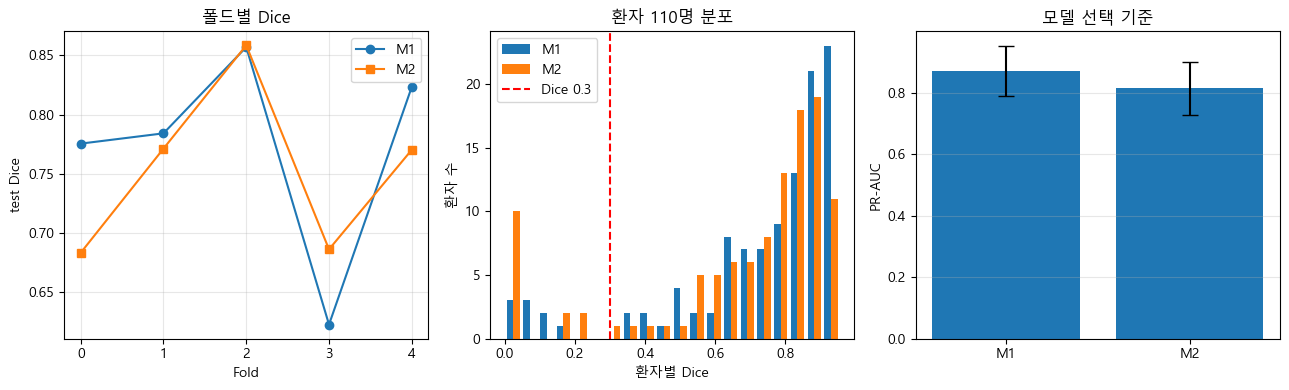

In [29]:
# [본인] 폴드별 Dice / 환자 분포 시각화
plt.figure(figsize=(13, 4))
plt.subplot(1, 3, 1)
plt.plot(cv1["fold"], cv1["dice"], "o-", label="M1")
plt.plot(cv2_["fold"], cv2_["dice"], "s-", label="M2")
plt.xlabel("Fold"); plt.ylabel("test Dice"); plt.title("폴드별 Dice")
plt.legend(); plt.grid(alpha=0.3)

plt.subplot(1, 3, 2)
plt.hist([s1.values, s2.values], bins=20, label=["M1","M2"])
plt.axvline(0.3, ls="--", c="r", label="Dice 0.3")
plt.xlabel("환자별 Dice"); plt.ylabel("환자 수")
plt.title(f"환자 {len(s1)}명 분포"); plt.legend()

plt.subplot(1, 3, 3)
plt.bar(["M1","M2"], [cv1["prauc"].mean(), cv2_["prauc"].mean()],
        yerr=[cv1["prauc"].std(), cv2_["prauc"].std()], capsize=6)
plt.ylabel("PR-AUC"); plt.title("모델 선택 기준"); plt.grid(axis="y", alpha=0.3)
plt.tight_layout(); plt.show()

---
# 11. 심화 분석

`# [배지수]` 환자 3D Dice, TP·FP·FN·TN 픽셀 분석, 종양 크기 구간별 성능.

## 11-1. 환자 3D Dice

환자의 모든 슬라이스를 하나의 3차원 덩어리로 보고 Dice 를 계산한다.
슬라이스별 Dice 평균보다 임상적 의미가 크다 — 실제 종양은 3차원 구조이기 때문이다.

In [30]:
# [배지수] 환자 3D Dice + 부트스트랩 신뢰구간
p3d = best_sl.groupby("patient")[["tp","fp","fn","tn"]].sum()
p3d["dice3d"] = 2*p3d["tp"] / (2*p3d["tp"] + p3d["fp"] + p3d["fn"]).clip(lower=1)

rng = np.random.default_rng(SEED)
vals = p3d["dice3d"].to_numpy()
boot = [vals[rng.integers(0, len(vals), len(vals))].mean() for _ in range(10000)]
lo, hi = np.percentile(boot, [2.5, 97.5])

print(f"환자 3D Dice  (n={len(p3d)})")
print(f"  평균 {vals.mean():.4f}   중앙값 {np.median(vals):.4f}   최소 {vals.min():.4f}")
print(f"  95% 부트스트랩 CI [{lo:.4f}, {hi:.4f}]")
print()
print("슬라이스 평균 Dice 와 비교")
print(f"  3D Dice        {vals.mean():.4f}")
print(f"  환자별 Dice     {pd.Series(best_pd).mean():.4f}")

환자 3D Dice  (n=110)
  평균 0.7250   중앙값 0.8131   최소 0.0000
  95% 부트스트랩 CI [0.6773, 0.7678]

슬라이스 평균 Dice 와 비교
  3D Dice        0.7250
  환자별 Dice     0.7250


## 11-2. TP · FP · FN · TN 픽셀 분석

오탐과 놓침을 픽셀 단위로 분해한다. 실패 유형 분석(12절)의 정량적 근거가 된다.

픽셀 수 confusion matrix
        예측 종양     예측 배경
실제 종양  514397    148597
실제 배경  154193  63555549

실제 클래스별 비율(%)
       예측 종양  예측 배경
실제 종양  77.59  22.41
실제 배경   0.24  99.76

  TP  맞힌 종양           514,397
  FN  놓친 종양           148,597   (종양의 22.4%)
  FP  가짜 종양           154,193
  TN  맞힌 정상        63,555,549


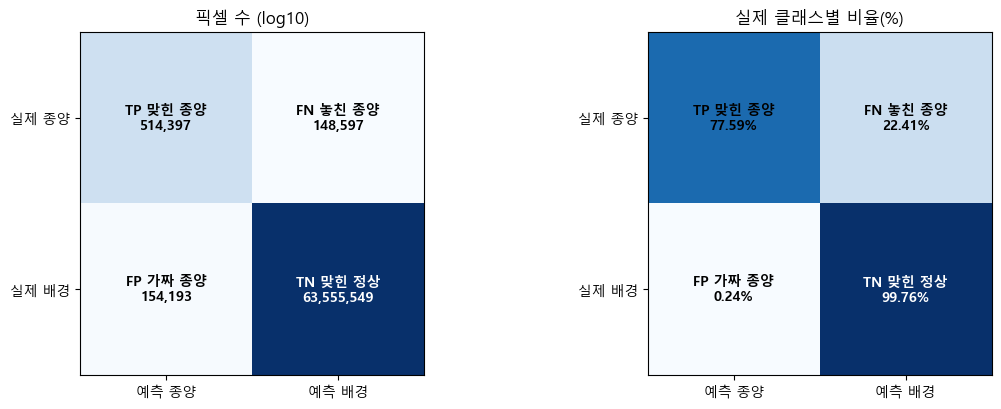

In [31]:
# [배지수] 픽셀 수준 confusion matrix
tot = best_sl[["tp","fp","fn","tn"]].sum()
conf = pd.DataFrame({"예측 종양": [tot.tp, tot.fp],
                     "예측 배경": [tot.fn, tot.tn]},
                    index=["실제 종양", "실제 배경"])
print("픽셀 수 confusion matrix")
print(conf.to_string())
print()
row_pct = conf.div(conf.sum(axis=1), axis=0) * 100
print("실제 클래스별 비율(%)")
print(row_pct.round(2).to_string())
print()
print(f"  TP  맞힌 종양      {tot.tp:>12,}")
print(f"  FN  놓친 종양      {tot.fn:>12,}   (종양의 {tot.fn/(tot.tp+tot.fn)*100:.1f}%)")
print(f"  FP  가짜 종양      {tot.fp:>12,}")
print(f"  TN  맞힌 정상      {tot.tn:>12,}")

fig, axes = plt.subplots(1, 2, figsize=(12, 4.2))
axes[0].imshow(np.log10(conf.to_numpy() + 1), cmap="Blues")
axes[0].set_title("픽셀 수 (log10)")
axes[1].imshow(row_pct.to_numpy(), cmap="Blues", vmin=0, vmax=100)
axes[1].set_title("실제 클래스별 비율(%)")
names = np.array([["TP 맞힌 종양", "FN 놓친 종양"], ["FP 가짜 종양", "TN 맞힌 정상"]])
for ax, vv, fmt in [(axes[0], conf.to_numpy(), ","), (axes[1], row_pct.to_numpy(), ".2f")]:
    ax.set_xticks([0,1], conf.columns); ax.set_yticks([0,1], conf.index)
    for r in range(2):
        for c in range(2):
            lab = f"{vv[r,c]:{fmt}}" + ("%" if fmt == ".2f" else "")
            ax.text(c, r, f"{names[r,c]}\n{lab}", ha="center", va="center",
                    color="white" if (r==1 and c==1) else "black", fontsize=10, fontweight="bold")
plt.tight_layout(); plt.show()

## 11-3. 종양 크기 구간별 성능

상관계수만으로는 "작은 종양을 못 찾는다"를 정량화하기 어렵다. 구간으로 나눠 본다.

       슬라이스수  평균_Dice  중앙값_Dice   평균_놓친픽셀   평균_종양픽셀
크기그룹                                               
작은 종양    460   0.4930    0.6243   49.5457  124.4587
중간 종양    455   0.7409    0.8640  102.3187  396.5912
큰 종양     458   0.8152    0.9067  173.0371  928.5895

작은 종양 vs 큰 종양 Dice 차이: 0.3222


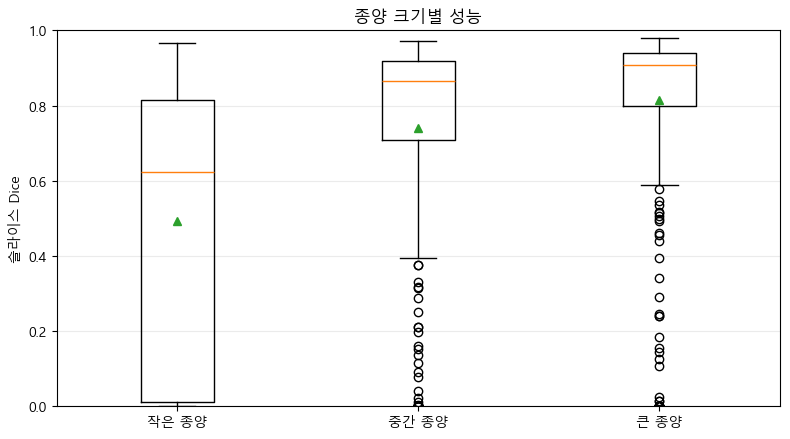

In [32]:
# [배지수] 종양 크기 3분위별 성능
pos_sl = best_sl[best_sl.tumor_px > 0].copy()
pos_sl["크기그룹"] = pd.qcut(pos_sl.tumor_px, q=3,
                             labels=["작은 종양","중간 종양","큰 종양"], duplicates="drop")
size_sum = pos_sl.groupby("크기그룹", observed=True).agg(
    슬라이스수=("dice","size"), 평균_Dice=("dice","mean"),
    중앙값_Dice=("dice","median"), 평균_놓친픽셀=("fn","mean"),
    평균_종양픽셀=("tumor_px","mean")).round(4)
print(size_sum.to_string())
print()
print(f"작은 종양 vs 큰 종양 Dice 차이: "
      f"{size_sum.loc['큰 종양','평균_Dice'] - size_sum.loc['작은 종양','평균_Dice']:.4f}")

plt.figure(figsize=(8, 4.5))
groups = [pos_sl.loc[pos_sl["크기그룹"] == l, "dice"].to_numpy()
          for l in ["작은 종양","중간 종양","큰 종양"]]
boxplot_compat(plt.gca(), groups, ["작은 종양","중간 종양","큰 종양"], showmeans=True)
plt.ylim(0, 1); plt.ylabel("슬라이스 Dice")
plt.title("종양 크기별 성능"); plt.grid(axis="y", alpha=0.25)
plt.tight_layout(); plt.show()

---
# 12. 오류 분석과 가설검정

`# [본인]` 실패 유형 분류, 임계값 민감도, 통계 검정.

th train:   0%|          | 0/2826 [00:00<?, ?it/s]

th val:   0%|          | 0/525 [00:00<?, ?it/s]

  th   dice  recall  vol_ratio
0.05 0.7280  0.9091     1.4976
0.10 0.7737  0.8938     1.3104
0.15 0.7957  0.8824     1.2179
0.20 0.8089  0.8723     1.1566
0.25 0.8179  0.8624     1.1088
0.30 0.8235  0.8523     1.0698
0.35 0.8279  0.8427     1.0357
0.40 0.8303  0.8322     1.0045
0.45 0.8316  0.8213     0.9754
0.50 0.8314  0.8096     0.9477
0.55 0.8301  0.7970     0.9204
0.60 0.8271  0.7824     0.8920
0.65 0.8229  0.7671     0.8643
0.70 0.8164  0.7486     0.8338
0.75 0.8082  0.7278     0.8011
0.80 0.7961  0.7019     0.7633
0.85 0.7771  0.6668     0.7162
0.90 0.7457  0.6161     0.6524
0.95 0.6764  0.5224     0.5446

th=0.50 Dice 0.8314  |  최고 0.8316 (th=0.45)  |  개선폭 +0.0002
고원 중앙 임계값 0.47


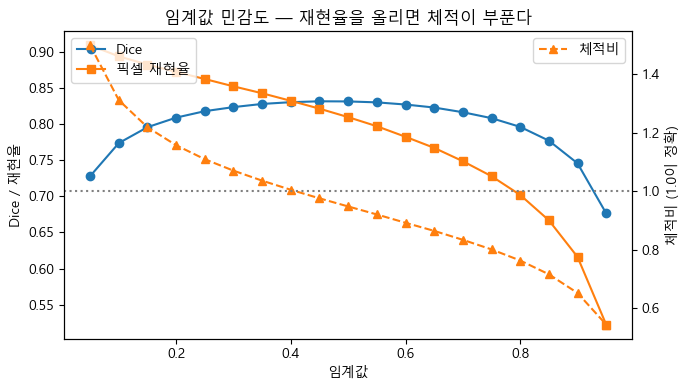

In [33]:
# [본인] 임계값 민감도 — 조정은 성능 향상이 아니라 운영점 이동
#         마지막 폴드 모델로 확인 (전체 재학습 불필요)
f_last = K_FOLDS - 1
test_p = df.loc[df.fold == f_last, "patient"].unique()
rest_p = df.loc[df.fold != f_last, "patient"].unique()
tr_p, va_p = train_test_split(rest_p, test_size=0.15, random_state=SEED)
sub_va = df[df.patient.isin(va_p)].reset_index(drop=True)
arr_tr = build_dataset(df[df.patient.isin(tr_p)].reset_index(drop=True), "th train")
mean_l, std_l = compute_norm_stats(arr_tr[0]); del arr_tr; gc.collect()
arr_va = build_dataset(sub_va, "th val")
va_ds = SegDataset(*arr_va, sub_va, mean_l, std_l, neg_ratio=None)
va_ld = DataLoader(va_ds, batch_size=BATCH_SIZE, shuffle=False,
                   num_workers=NUM_WORKERS, pin_memory=PIN_MEMORY)

m_last = UNet(base=BASE, use_bn=(BEST == "M2")).to(device)
m_last.load_state_dict(torch.load(f"lgg_{BEST}_f{f_last}.pt", map_location=device))
vp, vt = evaluate_seg(m_last, va_ld)
sw = threshold_sweep(vp, vt)
print(sw.round(4).to_string(index=False))
print()
print(f"th=0.50 Dice {sw.loc[sw.th==0.50,'dice'].values[0]:.4f}  |  "
      f"최고 {sw['dice'].max():.4f} (th={sw.loc[sw['dice'].idxmax(),'th']:.2f})  |  "
      f"개선폭 {sw['dice'].max() - sw.loc[sw.th==0.50,'dice'].values[0]:+.4f}")
print(f"고원 중앙 임계값 {pick_threshold(sw):.2f}")

fig, ax1 = plt.subplots(figsize=(7, 4))
ax1.plot(sw["th"], sw["dice"], "o-", label="Dice")
ax1.plot(sw["th"], sw["recall"], "s-", label="픽셀 재현율")
ax1.set_xlabel("임계값"); ax1.set_ylabel("Dice / 재현율"); ax1.legend(loc="upper left")
ax2 = ax1.twinx()
ax2.plot(sw["th"], sw["vol_ratio"], "^--", color="tab:orange", label="체적비")
ax2.axhline(1.0, ls=":", c="gray"); ax2.set_ylabel("체적비 (1.0이 정확)")
ax2.legend(loc="upper right")
plt.title("임계값 민감도 — 재현율을 올리면 체적이 부푼다")
plt.tight_layout(); plt.show()

In [34]:
# [본인] 실패 유형 분류 — 상·하위 환자
ps = pd.Series(best_pd, name="dice").to_frame()
ps["inst"] = [p.split("_")[1] for p in ps.index]
pv = best_sl.groupby("patient").agg(
    슬라이스=("dice","size"), 종양슬라이스=("tumor_px", lambda x: (x>0).sum()),
    평균종양px=("tumor_px", lambda x: x[x>0].mean() if (x>0).any() else 0),
    체적비=("pred_px", "sum"))
pv["체적비"] = pv["체적비"] / best_sl.groupby("patient")["tumor_px"].sum().clip(lower=1)
ps = ps.join(pv)

print("=== 하위 5명 ===")
print(ps.nsmallest(5, "dice").round(3).to_string())
print()
print("=== 상위 5명 ===")
print(ps.nlargest(5, "dice").round(3).to_string())
print()
c = ps[["dice","종양슬라이스","평균종양px"]].corr()["dice"]
print("환자별 Dice 와의 상관")
print(f"  종양 슬라이스 수  {c['종양슬라이스']:+.3f}  (설명력 {c['종양슬라이스']**2*100:.1f}%)")
print(f"  평균 종양 크기    {c['평균종양px']:+.3f}  (설명력 {c['평균종양px']**2*100:.1f}%)")

=== 하위 5명 ===
                        dice inst  슬라이스  종양슬라이스   평균종양px     체적비
TCGA_FG_7637_20000922  0.000   FG    51      18  408.833   0.000
TCGA_DU_7306_19930512  0.000   DU    42      13  404.846   0.000
TCGA_FG_A60K_20040224  0.013   FG    73      24   81.667  22.440
TCGA_HT_A61A_20000127  0.049   HT    88      37  371.243   0.025
TCGA_CS_6188_20010812  0.054   CS    24       4  132.250   0.049

=== 상위 5명 ===
                        dice inst  슬라이스  종양슬라이스   평균종양px    체적비
TCGA_HT_8114_19981030  0.954   HT    22      11  684.818  0.962
TCGA_HT_7684_19950816  0.945   HT    25      10  890.000  1.036
TCGA_DU_6399_19830416  0.945   DU    53      19  333.632  1.027
TCGA_DU_5871_19941206  0.940   DU    36      15  637.933  1.030
TCGA_DU_6400_19830518  0.937   DU    57      18  517.500  0.958

환자별 Dice 와의 상관
  종양 슬라이스 수  +0.023  (설명력 0.1%)
  평균 종양 크기    +0.368  (설명력 13.6%)


대응표본 순열검정 (100,000회 무작위, 환자 n=110)
  M1 중앙값 0.8131  /  M2 중앙값 0.7852
  중앙값 차이 (M2-M1)  -0.0212
  M2 가 나은 환자      30 / 110
  p = 0.0168   95% CI [-0.0845, -0.0077]

판정: H0 기각
주의: n이 작으면 검정력이 낮다. p값과 함께 중앙값 차이·신뢰구간을 보고할 것


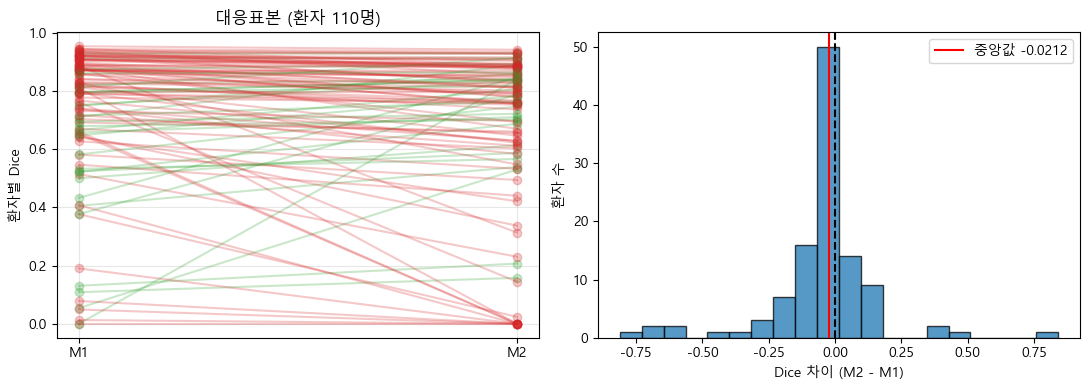

In [35]:
# [본인] 가설검정 — 환자 단위 대응표본
#         검정 단위가 슬라이스가 아니라 환자인 이유:
#         동일 환자의 인접 슬라이스는 거의 같은 영상이라 독립 표본이 아니다
def perm_test(diff, n_perm=100000, seed=SEED):
    n = len(diff)
    if n <= 22:                                   # 전수 계산 가능
        signs = ((np.arange(2**n)[:, None] >> np.arange(n)) & 1) * 2 - 1
        null = (signs * np.abs(diff)).mean(axis=1)
        return float((np.abs(null) >= abs(diff.mean()) - 1e-12).mean()), "전수"
    rng = np.random.default_rng(seed)
    null = [(rng.choice([-1, 1], n) * np.abs(diff)).mean() for _ in range(n_perm)]
    return float((np.abs(null) >= abs(diff.mean()) - 1e-12).mean()), f"{n_perm:,}회 무작위"

def boot_ci(diff, n_boot=10000, seed=SEED):
    rng = np.random.default_rng(seed)
    b = [diff[rng.integers(0, len(diff), len(diff))].mean() for _ in range(n_boot)]
    return np.percentile(b, [2.5, 97.5])

pat = sorted(set(pd1) & set(pd2))
a = np.array([pd1[p] for p in pat]); b = np.array([pd2[p] for p in pat])
diff = b - a
p_val, method = perm_test(diff)
lo_, hi_ = boot_ci(diff)

print(f"대응표본 순열검정 ({method}, 환자 n={len(pat)})")
print(f"  M1 중앙값 {np.median(a):.4f}  /  M2 중앙값 {np.median(b):.4f}")
print(f"  중앙값 차이 (M2-M1)  {np.median(diff):+.4f}")
print(f"  M2 가 나은 환자      {(diff>0).sum()} / {len(pat)}")
print(f"  p = {p_val:.4f}   95% CI [{lo_:+.4f}, {hi_:+.4f}]")
print()
print("판정:", "H0 기각" if p_val < 0.05 else "H0 기각 실패 — '차이 없음'이 아니라 '차이를 확인하지 못함'")
print("주의: n이 작으면 검정력이 낮다. p값과 함께 중앙값 차이·신뢰구간을 보고할 것")

plt.figure(figsize=(11, 4))
plt.subplot(1, 2, 1)
for i in range(len(pat)):
    plt.plot([0, 1], [a[i], b[i]], "o-", alpha=0.25,
             color="tab:green" if diff[i] > 0 else "tab:red")
plt.xticks([0, 1], ["M1", "M2"]); plt.ylabel("환자별 Dice")
plt.title(f"대응표본 (환자 {len(pat)}명)"); plt.grid(alpha=0.3)
plt.subplot(1, 2, 2)
plt.hist(diff, bins=20, edgecolor="k", alpha=0.75)
plt.axvline(0, ls="--", c="k"); plt.axvline(np.median(diff), c="r",
                                            label=f"중앙값 {np.median(diff):+.4f}")
plt.xlabel("Dice 차이 (M2 - M1)"); plt.ylabel("환자 수"); plt.legend()
plt.tight_layout(); plt.show()

---
# 13. 결과 저장

In [36]:
# [본인] results.json
summary = {
    "환경": ENV,
    "설정": {"IMAGE_SIZE": IMAGE_SIZE, "MIN_PX": MIN_PX, "K_FOLDS": K_FOLDS,
             "BASE": BASE, "BATCH": BATCH_SIZE, "EPOCHS": EPOCHS,
             "NEG_RATIO": NEG_RATIO, "LR": BEST_LR, "LOSS": BEST_LOSS, "SEED": SEED},
    "소실검증": {"완전소실": int((sz["small"]==0).sum()),
                 "5px미만": int((sz["small"]<5).sum()),
                 "평균축소율": float(sz["ratio"].mean())},
    "M0": M0_RESULT,
    "M1_폴드평균": {k: float(cv1[k].mean()) for k in
                    ["dice","dice_pos","iou","recall","precision","prauc","vol"]},
    "M2_폴드평균": {k: float(cv2_[k].mean()) for k in
                    ["dice","dice_pos","iou","recall","precision","prauc","vol"]},
    "폴드간표준편차": {"M1_dice": float(cv1["dice"].std()),
                       "M2_dice": float(cv2_["dice"].std())},
    "환자110명": {"M1_평균": float(s1.mean()), "M1_표준편차": float(s1.std()),
                  "M1_Dice03미만": int((s1<0.3).sum()),
                  "M2_평균": float(s2.mean()), "M2_표준편차": float(s2.std()),
                  "M2_Dice03미만": int((s2<0.3).sum())},
    "3D_Dice": {"평균": float(vals.mean()), "CI95": [float(lo), float(hi)]},
    "검정": {"n": len(pat), "p": p_val, "중앙값차이": float(np.median(diff)),
             "CI95": [float(lo_), float(hi_)]},
    "최종모델": BEST,
}
with open("results.json", "w", encoding="utf-8") as f:
    json.dump(summary, f, ensure_ascii=False, indent=2)
best_sl.to_csv("slice_records.csv", index=False, encoding="utf-8-sig")
pd.Series(best_pd, name="dice").to_csv("patient_dice.csv", encoding="utf-8-sig")
print("results.json / slice_records.csv / patient_dice.csv 저장 완료")
print(json.dumps(summary, ensure_ascii=False, indent=2)[:1800])

results.json / slice_records.csv / patient_dice.csv 저장 완료
{
  "환경": {
    "OS": "Windows 10",
    "Python": "3.10.11",
    "torch": "2.11.0+cu128",
    "CUDA": "12.8",
    "GPU": "NVIDIA GeForce RTX 5060 Laptop GPU",
    "numpy": "1.26.4",
    "pandas": "2.3.3",
    "opencv": "4.11.0",
    "sklearn": "1.7.2",
    "matplotlib": "3.10.9",
    "SEED": 42
  },
  "설정": {
    "IMAGE_SIZE": 128,
    "MIN_PX": 5,
    "K_FOLDS": 5,
    "BASE": 32,
    "BATCH": 16,
    "EPOCHS": 30,
    "NEG_RATIO": 1.0,
    "LR": 0.001,
    "LOSS": "BCE",
    "SEED": 42
  },
  "소실검증": {
    "완전소실": 0,
    "5px미만": 2,
    "평균축소율": 0.25033985385880914
  },
  "M0": {
    "dice": 0.12886187280403177,
    "pixel_recall": 0.45658633411463756,
    "vol": 6.086445729523947,
    "slice_recall": 1.0,
    "slice_precision": 0.3646746347941567,
    "bg_accuracy": 0.9897007018623537
  },
  "M1_폴드평균": {
    "dice": 0.772441533753874,
    "dice_pos": 0.8029572291225759,
    "iou": 0.635862340730414,
    "recall": 0.8827444694

---
# 14. 참고 — 사전학습 인코더 적용 가능성

`# [윤동길]` **본 연구 범위 밖의 예비 실험이다.**

본 연구는 수업에서 다룬 라이브러리 범위(`torch`, `numpy`, `pandas`, `cv2`,
`matplotlib`, `seaborn`, `sklearn`, `tqdm`) 내로 구현을 제한하였다.
성능 상한을 가늠하기 위해 별도로 `segmentation_models_pytorch` 의
ResNet34 ImageNet 사전학습 인코더를 적용한 예비 실험을 수행하였다.

## 실측 결과 (동일 5-Fold 조건, 128px, 10에폭)

| | 베이스라인 U-Net | 전이학습 (ResNet34) |
|---|---|---|
| pooled tumor Dice | 0.7131 | **0.8235** |
| pooled tumor IoU | 0.5541 | 0.7000 |
| Fold 평균 Dice | 0.7051 ± 0.0869 | 0.8200 ± 0.0334 |
| 환자별 평균 Dice | 0.5785 | 0.6851 |

환자 110명 대응표본 t검정에서 평균 차이 0.1066, p < 0.000001 로 유의하였다.

## 해석과 한계

- Fold 간 표준편차가 0.0869 에서 0.0334 로 감소하여 **안정성도 개선**되었다.
- 다만 이 향상은 **사전학습 효과와 디코더 아키텍처 차이가 혼재**된 값이다.
  `smp.Unet` 은 본 연구의 U-Net 과 디코더 구조·파라미터 수가 모두 다르다.
- 본 연구의 범위 제약상 **주 결과에는 포함하지 않으며**, 향후 과제로 남긴다.

아래 셀은 참고용이며 실행하지 않아도 무방하다.

In [37]:
# [윤동길] 참고 실험 — 본 연구 범위 밖. 실행하려면 아래 주석을 해제할 것
# import segmentation_models_pytorch as smp
#
# def make_transfer_model():
#     return smp.Unet(encoder_name="resnet34", encoder_weights="imagenet",
#                     in_channels=3, classes=1)
#
# cv_tr, pd_tr, sl_tr = run_cv(criterion_name="BCE+Dice", tag="TRANSFER")

print("참고 실험 셀 — 실행하지 않음 (본 연구 범위 밖)")

참고 실험 셀 — 실행하지 않음 (본 연구 범위 밖)


---
# 15. 결론

## 주요 결과

| 항목 | 값 |
|---|---|
| 최종 모델 | PR-AUC 기준 선정 (10절 참조) |
| 검증 방식 | 환자 단위 5-Fold, 환자 110명 전원 평가 |
| 입력 크기 | 128×128 (소실 검증 통과) |

## 도달 수준 — 도메인 기준과의 비교

| 기준 | Dice | 출처 |
|---|---|---|
| BraTS 2020 우승 (nnU-Net) | 0.8895 | Isensee et al., arXiv 2011.00848 |
| 이 데이터셋 원논문 — "인간 수준에 필적" | 0.82 | Buda et al., Comput Biol Med 2019 |
| **인간 판독자 간 일치도** | **0.74 ~ 0.85** | Menze et al., IEEE TMI 2015 (BraTS) |
| 간세포암 판독자 간 / 동일인 재판독 | 0.79 / 0.85 | PMC9772368 (p<0.001) |
| 참고 실험 (전이학습) | 0.8235 | 14절 |
| 규칙 기반 (M0) | 8절 참조 | — |

**전문가 판독자끼리도 Dice 0.74~0.85 로만 일치한다.** Dice 1.0 은 도달 가능한 목표가 아니다.
BraTS 논문은 저등급 종양이 T1c 조영증강 부재로 분할 신호가 약함을 지적하며,
**본 데이터셋은 전부 저등급이다.**

## 본 연구가 수행한 검증

1. **방법론적 엄밀성** — 환자 단위 층화 분할, 슬라이스 분할 시 100% 누수 실증,
   폴드별 정규화 통계·임계값 재계산으로 누수 차단
2. **입력 크기 사전 검증** — 128px 축소 시 종양 소실 0장 확인, MIN_PX 면적 비율 환산
3. **지표의 타당성** — 규칙 기반 베이스라인으로 픽셀 정확도와 재현율 단독 사용의 부당성 실증
4. **결과의 안정성** — 5-Fold 로 환자 110명 전원 평가, 폴드 간 표준편차 보고
5. **심화 분석** — 3D Dice, 픽셀 수준 오류 분해, 종양 크기 구간별 성능

## 한계

| 항목 | 내용 |
|---|---|
| 표본 크기 | 환자 110명. 폴드 간 편차가 크면 단일 값으로 보고하기 어렵다 |
| 2D 처리 | 슬라이스 간 3차원 연속성을 입력 단계에서 활용하지 못했다 |
| 후처리 미적용 | 원논문은 최대 연결성분 후처리를 적용한다 |
| 전이학습 제외 | 라이브러리 범위 제약. 14절에 예비 결과만 제시 |
| EZ 기관 | 환자 1명으로 기관별 일반화 판단 불가 |
| 정답의 성격 | FLAIR 이상 소견이지 병리학적 경계가 아니며 관찰자 변동이 존재한다 |

## 향후 과제

- 최대 연결성분 후처리 적용 (원논문 방식)
- 2.5D 또는 3D 입력으로 슬라이스 간 연속성 활용
- 사전학습 인코더를 수업 범위 내(`timm`)에서 재구현
- 다기관 외부 데이터 검증